# Логистическая регрессия

Ранее мы познакомились с методами классификации, основанными на порождающих моделях, также мы познакомились с методом ближайших соседей. На этой паре мы познакомимся с методом классификации, который используется повсеместно в нейронных сетях, применяемых для классификации. 

Этот метод называется логистической регрессией. Название метода возникает из его математического смысла. Снова рассмотрим случай классификации объектов на два класса и запишем теорему Байеса:

$$p(C_1|x)=\frac{p(C_1)P(x|C_1)}{p(C_1)P(x|C_1) + p(C_2)P(x|C_2)} = \frac{1}{1+\frac{p(C_2)P(x|C_2)}{p(C_1)P(x|C_1)}}.$$

Далее возникает идея попытаться смоделировать:

$$\frac{p(C_2)P(x|C_2)}{p(C_1)P(x|C_1)}=w^\top x.$$

Причём можно заметить, что $\frac{p(C_2)P(x|C_2)}{p(C_1)P(x|C_1)}=\frac{p(C_2|x)}{p(C_1|x)}$ - величина, называемая <b>шансом</b>.

Но оказывается, что шанс может принимать значения в диапазоне $(0,+\infty)$, а функция $w^\top x$ в диапазоне $(-\infty,+\infty)$. 

Поэтому, извлечём из шанса логарифм, чтобы интервалы совпадали, то есть мы приходим к такому выражению:

$$p(C_1|x) = \frac{1}{1+e^{-\log\frac{p(C_1)P(x|C_1)}{p(C_2)P(x|C_2)}}}.$$

И мы будем строить модель, чтобы описать 

$$\log\frac{p(C_1)P(x|C_1)}{p(C_2)P(x|C_2)}=w^\top x.$$

Введём функцию логистического сигмоида:

$$\sigma(a)=\frac{1}{1+e^{-a}}.$$

Получается, что мы строим модель вида $p(C_1|x)=\sigma(w^\top x)$, отсюда и появляется имя логистической регрессии.

У сигмоидальной функции есть некоторые важные свойства:

- Обратная функция к сигмоиде называется <b>логитом</b>: $logit(p)=\log\frac{p}{1-p}$, для $p\in(0,1)$
- сигмоида симметрична относительно нуля: $\sigma(-a)=\frac{1}{1+e^a}=\frac{e^{-a}}{e^{-a}+1}=1-\sigma(a)$
- Производную сигмоиды можно выразить через саму сигмоиду: $\sigma'(a) = \frac{-e^{-a}}{(1+e^{-a})^2} = \frac{1}{1+e^{-a}}\frac{e^{-1}}{1+e^{-a}}=\sigma(a)(1-\sigma(a))$.

## Максимизация правдоподобия

Вернёмся к нашей модели. Мы моделируем вероятности принадлежностей классам следующим образом:

$$p(C_1|x)=\sigma(w^\top x)\;\;\;\;\;p(C_2|x)=1-p(C_1|x)=1-\sigma(w^\top x).$$

Запишем правдоподобие для набора данных $D=\{(x_i,t_i)\}_{i=1}^n$, где $t_i=1$, если $x_i\in C_1$, $t_i=0$, если $x_i\in C_2$:

$$p(D|w)=\prod_{i=1}^np(C_1|x_i,w)^{t_i}p(C_2|x_i,w)^{1-t_i}=\prod_{i=1}^n\sigma(w^\top x_i)^{t_i}(1-\sigma(w^\top x_i))^{1-t_i}.$$

Запишем логарифм правдоподобия:

$$\ln p(D|w)=\sum_{i=1}^nt_i\ln\sigma(w^\top x_i)+(1-t_i)\ln(1-\sigma(w^\top x_i)).$$

Чтобы получить функцию ошибки, которую мы будем минимизировать необходимо домножить на $-1$.


С аналитическим решением для логистической регрессии уже не так просто, но мо можем всё также пользоваться градиентным спуском.

Вычислим градиент:

$$\nabla_w\ln p(D|w)=\sum_{i=1}^nt_i\frac{\sigma'(w^\top x_i)}{\sigma(w^\top x_i)}x_i+(1-t_i)\frac{\sigma'(w^\top x_i)}{1-\sigma(w^\top x_i)}x_i=
\sum_{i=1}^nt_i\frac{\sigma(w^\top x_i)(1-\sigma(w^\top x_i))}{\sigma(w^\top x_i)}x_i+\\+(1-t_i)\frac{\sigma(w^\top x_i)(1-\sigma'(w^\top x_i))}{1-\sigma(w^\top x_i)}x_i
= \sum_{i=1}^nt_i(1-\sigma(w^\top x_i))x_i+(1-t_i)\sigma(w^\top x_i)x_i=\sum_{i=1}^n(t_i-\sigma(w^\top x_i))x_i
$$

Мы даже можем посчитать Гессиан:

$$H=\nabla_w\nabla_w\ln p(D|w)=\sum_{i=1}^{n}\sigma_i(1-\sigma_i)x_nx_n^\top =X^\top RX,$$

где $\sigma_i=\sigma(wx_i)$, а R это диагональная матрица:

$$R=\begin{pmatrix}
\sigma_1(1-\sigma_1) & 0 & \dots & 0\\
0 & \sigma_2(1-\sigma_2) & \dots & 0\\
\vdots & \vdots & \ddots & \vdots \\
0 & 0 & \dots & \sigma_n(1-\sigma_n)
\end{pmatrix}.$$

Сходимости за один шаг как это было в линейной регрессии при использовании метода Ньютона тут не будет, но мы всё равно можем совершать шаги итеративно.

## Случай нескольких классов

Обобщим описанный выше метод на случай нескольких классов.

Пусть целевая переменная теперь кодируется как one-hot вектор, то есть $t_i=(0,\dots,1,\dots,0)$, $t_ik$ - это $k$-я компонента вектора $t_i$, количество классов равно $K$.

Составим следующую модель:

$$p(C_k|x)=\frac{e^{w_k^\top x}}{\sum_{i=1}^{K}e^{w_i^\top x}}.$$

То есть теперь с помощью $e^{w_kx}$ мы моделируем не шанс, а $p(C_k)p(x|C_k)$.

Использованная нами функция называется <b>softmax</b>:

$$softmax(x_k; x_1,\dots,x_K)=\frac{e^{x_k}}{\sum_{i=1}^Ke^{x_i}}$$

Правдоподобие записывается следующим образом:

$$p(D|W)=\prod_{i=1}^{n}\prod_{j=1}^K softmax(w_j^\top x_i;w_1^\top x_i,\dots,w_K^\top x_i)^{t_{ij}}$$

Логарифм правдоподобия:

$$\ln p(D|W)=\sum_{i=1}^{n}\sum_{j=1}^K t_{ij}\ln softmax(w_j^\top x_i;w_1^\top x_i,\dots,w_K^\top x_i)$$

Или, если обозначить $y_{ij}=softmax(w_j^\top x_i;w_1^\top x_i,\dots,w_K^\top x_i)$, то получим формулу:

$$\ln p(D|W)=\sum_{i=1}^{n}\sum_{j=1}^K t_{ij}\ln y_{ij}.$$

Поскольку выше описано правдоподобие, которое надо максимизировать, а в машинном обучении принято решать задачи минимизации. Отсюда возникает функции ошибки, основанная на кросс-энтропии:

$$CossEntripyLoss = -\sum_{i=1}^{n}\sum_{j=1}^K t_{ij}\ln y_{ij}.$$

Кросс энтропия записывается формулой: $$H(p||q)=\int p(x)\log q(x) dx = \sum_i p_i\log q_i,$$ в непрерывном и дискретном виде. 

Кросс энтропия является составной частью дивергенции Кульбака-Лейблера (KL-divergence), которая в свою очередь используется как несимметричное расстояние между распределениями, задаваемое формулой:

$$KL(p||q)=\int p(x)\ln\frac{p(x)}{q(x)}dx = \int p(x)\ln p(x)dx - \int p(x)\ln q(x)dx$$

Первый член  $\int p(x)\ln p(x)dx$ это энтропия распределения $p(x)$, а второй это кросс энтропия между этими распределениями.

KL-конвергенция всегда неотрицательна, но хоть свойство симметричности не выполнено, это не мешает использовать KL-конвергенцию как меру схожести двух распределений.

Таким образом, если мы хотим приблизить распределение $p(x)$ распределением $q(x)$, то нам необходимо минимизировать $KL(p||q)$, а поскольку от q зависит только второй член, то нам необходимо максимизировать $\int p(x)\ln q(x)dx$, то есть минимизировать $-\int p(x)\ln q(x)dx$, что и происходит при применении логистической регрессии.

Чтобы вычислить градиент функции ошибки, вычислим градиент по softmax:

$$\nabla_{w_k}y_{ik}=\nabla_{w_k}softmax(w_k^\top x_i;w_1^\top x_i,\dots,w_n^\top x_i)
=\nabla_{w_k}\left(\frac{e^{w_k^\top x_i}}{\sum_{j}e^{w_j^\top x_i}}\right)
=\\=\frac{\nabla_{w_k}(e^{w_k^\top x_i})\cdot\left(\sum_{j}e^{w_j^\top x_i}\right) - \nabla_{w_k}\left(\sum_{j}e^{w_j^\top x_i}\right) \cdot e^{w_k^\top x_i}}{\left(\sum_{j}e^{w_j^\top x_i}\right)^2}=\\=
\frac{e^{w_k^\top x_i}\cdot\left(\sum_{j}e^{w_j^\top x_i}\right)x_i - e^{w_k^\top x_i} \cdot e^{w_k^\top x_i} x_i}{\left(\sum_{j}e^{w_j^\top x_i}\right)^2}
=\\=
\frac{e^{w_k^\top x_i}}{\sum_{j}e^{w_j^\top x_i}}
\frac{\sum_{j}e^{w_j^\top x_i} - e^{w_k^\top x_i}}{\sum_{j}e^{w_j^\top x_i}}x_i
=\\=
softmax(w_k^\top x_i;w_1^\top x_i,\dots,w_n^\top x_i)\cdot (1-softmax(w_k^\top x_i;w_1^\top x_i,\dots,w_n^\top x_i))x_i=\\=y_{ik}(1-y_{ik})x_i
$$

$$\nabla_{w_k}y_{im}=\nabla_{w_k}softmax(w_m^\top x_i;w_1^\top x_i,\dots,w_n^\top x_i)
=\nabla_{w_k}\left(\frac{e^{w_m^\top x_i}}{\sum_{j}e^{w_j^\top x_i}}\right)
=\\=
-\frac{e^{w_m^\top x_i}}{\left(\sum_{j}e^{w_j^\top x_i}\right)^2}\cdot\nabla_{w_k}\left(\sum_{j}e^{w_j^\top x_i}\right)
=
-\frac{e^{w_m^\top x_i}}{\sum_{j}e^{w_j^\top x_i}}\frac{e^{w_k^\top x_i}}{\sum_{j}e^{w_j^\top x_i}}x_i
=\\=
-softmax(w_m^\top x_i;w_1^\top x_i,\dots,w_n^\top x_i)\cdot softmax(w_k^\top x_i;w_1^\top x_i,\dots,w_n^\top x_i)x_i=\\=-y_{im}y_{ik}x_i
$$

Наконец вычислим градиент по функции ошибки:

$$\nabla_{w_k}L=\nabla_{w_k}\left(-\sum_{i=1}^{n}\sum_{j=1}^K t_{ij}\ln y_{ij}\right)=-\sum_{i=1}^{n}\sum_{j=1}^Kt_{ij}\frac{1}{y_{ij}}\nabla_{w_k}(y_{ij})=
-\sum_{i=1}^{n}\left[t_{ik}(1-y_{ik})x_i-\sum_{j\neq k}t_{ij}y_{ij}x_i\right].
$$

Далее, можно учесть, что объект всегда принадлежит только одному классу, формулу можно сократить. То есть $t_{ij}\in\{0,1\}, \forall i,j$ и $\sum_{j=1}^K t_{ij}=1$. Получим:

$$\nabla_{w_k}L=-\sum_{i=1}^{n}(t_{ik}-y_{ik})x_i.$$

Ну и вот мы убедились, что случай классификации на много классов лишь немного сложнее.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, accuracy_score
from sklearn.frozen import FrozenEstimator

In [2]:
def ligistic_regression_example(n_points, mean, cov, target, penalty = None):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = LogisticRegression(penalty=penalty)
    model.fit(X, Y)

    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    x = np.linspace(xmin, xmax, 300)
    y = np.linspace(ymin, ymax, 300)
    # создаём две матрицы с координатами x и y
    x, y = np.meshgrid(x, y)
    # Преобразуем матрицу в строчку
    xx = x.reshape(-1, 1)
    yy = y.reshape(-1, 1)
    points = np.hstack([xx,yy])
    # Передаём строчку точек в функцию
    probs = model.predict_proba(points) # Получаем вероятности
    # Получаем самый вероятный класс
    predicts = probs.argmax(axis=1)
    # Получаем вероятность этого класса
    # probs = probs.max(axis=1)
    # Преобразуем строчку обратно в матрицу
    predicts = predicts.reshape(x.shape)
    # probs = probs.reshape(x.shape)
    probs = probs.reshape((*x.shape, -1))
    # рисуем деление плоскости на классы
    for i in range(model.classes_.shape[0]):
        plt.pcolormesh(x, y, np.ones_like(x) * target[i], cmap="tab10", vmin=1, vmax=10,
                   alpha=probs[:, :, i]) # Вероятность передаём в альфа-канал
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="bright", legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)

Разделение на два класса:

(-4.0, 8.0)

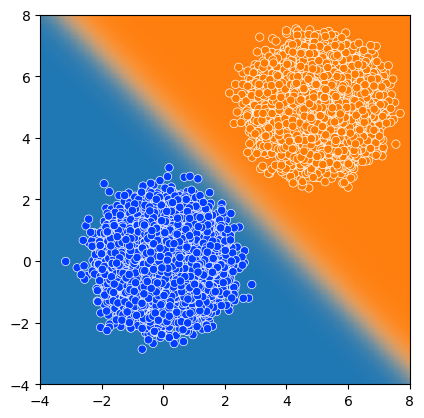

In [45]:
# Задаём параметры для генерации точек
# Количество точек
train_n_points = np.array([30000, 30000])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.5, 0],
      [0, 0.5]],
     [[0.5, 0],
      [0, 0.5]]]
    )
ligistic_regression_example(train_n_points, mean, cov, target)
plt.xlim(-4,8)
plt.ylim(-4,8)

Не будем забывать, что к логистической регрессии всё также можно применять уже знакомые нам методы регуляризации: L1, L2, Elastic.

(-4.0, 8.0)

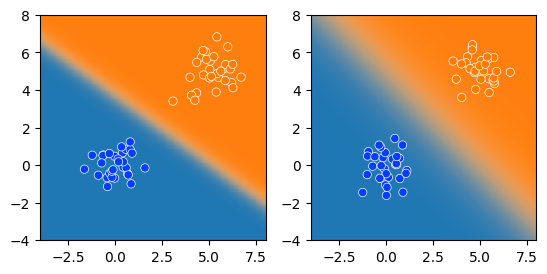

In [35]:
# Задаём параметры для генерации точек
# Количество точек
train_n_points = np.array([30, 30])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.5, 0],
      [0, 0.5]],
     [[0.5, 0],
      [0, 0.5]]]
    )
plt.subplot(121)
ligistic_regression_example(train_n_points, mean, cov, target)
plt.xlim(-4,8)
plt.ylim(-4,8)
plt.subplot(122)
ligistic_regression_example(train_n_points, mean, cov, target, penalty="l2")
plt.xlim(-4,8)
plt.ylim(-4,8)

На примере двух точек явно видна польза регуляризации: 

(-4.0, 8.0)

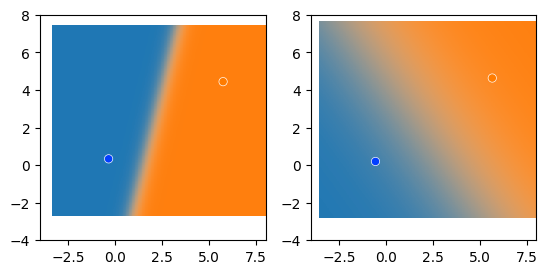

In [36]:
train_n_points = np.array([1, 1])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.5, 0],
      [0, 0.5]],
     [[0.5, 0],
      [0, 0.5]]]
    )
plt.subplot(121)
ligistic_regression_example(train_n_points, mean, cov, target)
plt.xlim(-4,8)
plt.ylim(-4,8)
plt.subplot(122)
ligistic_regression_example(train_n_points, mean, cov, target, penalty="l2")
plt.xlim(-4,8)
plt.ylim(-4,8)

Добавление третьего кластера ничего не портит, не смещает разделяющую поверхность:

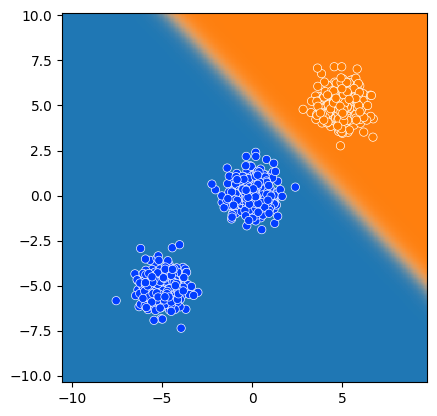

In [6]:
# Задаём параметры для генерации точек
# Количество точек
train_n_points = np.array([300, 300, 300])
target = np.array([1, 2, 1])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5], [-5,-5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.5, 0],
      [0, 0.5]],
     [[0.5, 0],
      [0, 0.5]],
     [[0.5, 0],
      [0, 0.5]]]
    )
ligistic_regression_example(train_n_points, mean, cov, target)

Классификация на несколько классов выглядит естественно:

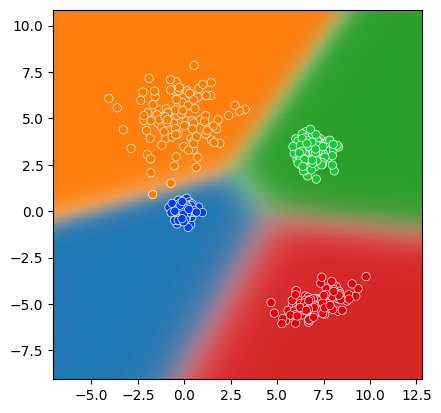

In [7]:
train_n_points = np.array([100, 100, 100, 100])
target = np.array([1, 2, 3, 4])
# Среднее центров гауссианов
mean = np.array([[0, 0], [0, 5], [7, 3], [7, -5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.1, 0],
      [0, 0.1]],
     [[2, 0],
      [0, 2]],
     [[0.3, 0],
      [0, 0.3]],
     [[1, 0.3],
      [0.3, 0.3]]]
    )
ligistic_regression_example(train_n_points, mean, cov, target, penalty="l2")

Если увеличить дисперсию шума:

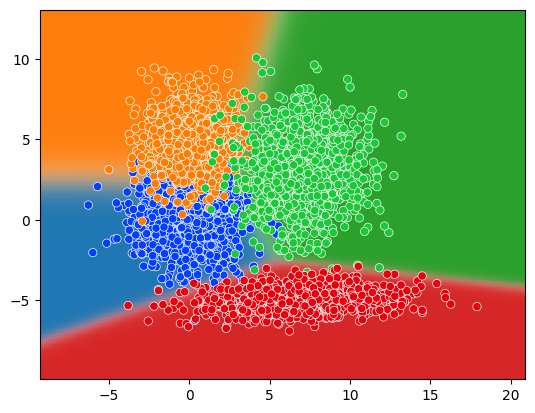

In [8]:
train_n_points = np.array([1000, 1000, 1000, 1000])
target = np.array([1, 2, 3, 4])
# Среднее центров гауссианов
mean = np.array([[0, 0], [0, 5], [7, 3], [7, -5]])
# Матрицы коварианцй
cov = np.array(
    [[[3, 0],
      [0, 3]],
     [[2, 0],
      [0, 2]],
     [[4, 0],
      [0, 5]],
     [[10, 0.3],
      [0.3, 0.4]]]
    )
ligistic_regression_example(train_n_points, mean, cov, target, penalty="l2")

## Калибровка классификаторов

Хорошо, мы получили хорошую модель которая при выполнении своего предположения (что логарифм шанса можно описать линейной функцией) будет давать хорошие вероятности. Но как проверить, что вероятность которую нам предсказала модель верна? 

Но вообще, не всё ли нам равно модель дала точный ответ о принадлежности классу (без вероятности), вероятность $0.9$ или вероятность $0.6$? 

При простой классификации объектов на два класса: кошки, собаки - нам и правда нет особой разницы между точным ответом и предсказанной вероятностью. А вот если мы предсказываем, к примеру, будет завтра дождь или нет, нам уже нужен не точечный ответ, а именно вероятность. Разница между вероятностью $0.49$ и вероятностью $0.51$ не велика, а точечный ответ изменится. Но и в том и в том случае стоит взять с собой зонт. На самом деле, даже вероятности дождя $0.1$ уже достаточно чтобы обеспокоиться и захватить зонт. 

Получается, что вероятность нам важна в том случае, если классы имеют разное значение и даже небольшая вероятность события имеет большое значение.

### Способы оценки калибровки классификаторов

С мотивацией мы разобрались, а теперь займёмся калибровкой классификаторов.

#### 1. Наглядный метод

Как проверить, что классификатор выдаёт верные вероятности? Давайте возьмём 100 объектов, для которых предсказана вероятность $0.8$ тогда примерно $80$ объектов действительно должны принадлежать заданному классу. А чтобы проверить калибровку необходимо просто по имеющимся данным вычислить оценку вероятности. К примеру, окажется что лишь $60$ точек принадлежат предсказанному классу. Это значит, что классификатор слишком уверен в своих предсказаниях $-$ он должен был предсказать вероятность $0.6$, а предсказал $0.8$.

Следуя этой идее можно построить целый график. Для этого разобьём отрезок от 0 до 1 на k равных отрезков (обычно 10). Далее найдём предсказания вероятности, получаемые от модели, сгруппируем по полученным отрезкам и посчитаем оценки вероятностей по данным для каждого отрезка. Соотношение центров отрезков (предсказанных моделью вероятностей) и полученным по данным оценкам отражает качество калибровки. Чем получаемая прямая ближе к отрезку $(0,0)$-$(1,1)$ тем калибровка лучше.

На изображении нарисованы примеры графиков, получаемых описанным методом. Сразу можно выделить некоторые "типы" классификаторов: слишком уверенные и недостаточно уверенные. 

**Слишком уверенные** завышают оценки вероятности классов. Пример приведён на самом правом графике, где видно что модель вместо вероятности $0.6$ предсказывает $0.8$.

**Недостаточно уверенные** занижают оценки вероятности классов. Пример приведён на самом левом графике, где видно что модель вместо вероятности $0.9$ предсказывает $0.8$.

<img style="width: 75%; max-width: 960px; display: block; margin: 0 auto;" src="https://i.postimg.cc/SKp0rz3t/calibration-showcase.png"/>



#### 2. Численные метрики

Для оценки качества калибровки используют две основные метрики. Первая это непосредственно функция ошибки, которая является логарифмом правдоподобия (отсюда индекс LL):

$$\varphi_{LL}=-\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^Kt_{ij}\log y_{ij}.$$

Трудности использования такой метрики для оценки калибровки очевидны. Поэтому чаще на практике используют **индекс Брайера** (Brier score): 
$$\varphi_{BS}=\frac{1}{N}\sum_{i=1}^N\sum_{k=1}^K(t_{ij}-y_{ij})^2.$$

Индекс Брайера принимает значения в интервале от 0 до 1, чем он ближе к 0, тем лучше.

In [9]:
def gen_train_test_smes(mean, cov, target, train_n_points, test_n_points):
    X_train, X_test = [], []
    Y_train, Y_test = [], []
    # Генерация точек из каждого гауссиана
    for i in range(0, train_n_points.shape[0]):
        X_train.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=train_n_points[i]))
        Y_train.append(np.ones(train_n_points[i]) * target[i])
        
        X_test.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=test_n_points[i]))
        Y_test.append(np.ones(test_n_points[i]) * target[i])
    return np.concatenate(X_train), np.concatenate(X_test), np.concatenate(Y_train), np.concatenate(Y_test)

def caliber_models(X_test, Y_test, models, bins=10):
    fig, axes = plt.subplots(1,len(models))
    axes = axes.flatten()
    fig.set_size_inches(18,6)

    # расстановка центров отрезков и вычисление ширины отрезков
    width = 1 / bins
    start,end = width/2, 1 - width/2
    bin_centers = np.linspace(start, end, bins)

    eps = 1e-5
    for index, (name, model) in enumerate(models):
        # предсказание вероятности
        prob = model.predict_proba(X_test)
        # вычисление метрик оценки качества калибровки
        score = brier_score_loss(Y_test, prob[:,-1])
        accuracy = accuracy_score(Y_test, model.classes_[np.argmax(prob, axis=1)])
        # вычисление маски того, что вероятность попадает в рассматриваемый отрезок
        mask = np.abs(bin_centers[:,None] - prob[None, :, 1]) <= width/2 + eps
        # вычисление количества точек данных попавших в каждый отрезок
        bin_sum = np.sum(mask, axis=1)
        bin_sum = bin_sum + (bin_sum == 0) # замена 0 на 1 чтобы не было деления на 0
        # вычисление оценки вероятности по имеющимся данным
        bin_true_cls = np.sum(mask * (Y_test[None, :]-1), axis=1)
        
        axes[index].plot([0],[0], c="w", label=(r"$\varphi_{BS}=%.5f$" % score))
        axes[index].plot([0],[0], c="w", label=(r"$Accuracy=%.5f$" % accuracy))
        axes[index].bar(bin_centers, bin_true_cls / bin_sum
                        , width=width*0.95, color="black", alpha=0.3)
        axes[index].plot(bin_centers, bin_centers, label="Perfect calibration.")
        axes[index].legend()
        axes[index].set_title(name)
        axes[index].set_aspect("equal")
        axes[index].set_xlabel("Predicted probability")
    axes[0].set_ylabel("True probability")
        
def draw_descision_surface(ax, X, Y, model, scatter_alpha=0.2, mesh_alpha=0.5):
     # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    x = np.linspace(xmin, xmax, 300)
    y = np.linspace(ymin, ymax, 300)
    # создаём две матрицы с координатами x и y
    x, y = np.meshgrid(x, y)
    # Преобразуем матрицу в строчку
    xx = x.reshape(-1, 1)
    yy = y.reshape(-1, 1)
    points = np.hstack([xx,yy])
    # Передаём строчку точек в функцию
    probs = model.predict_proba(points) # Получаем вероятности
    # Получаем самый вероятный класс
    predicts = probs.argmax(axis=1)
    # Получаем вероятность этого класса
    # probs = probs.max(axis=1)
    # Преобразуем строчку обратно в матрицу
    predicts = predicts.reshape(x.shape)
    # probs = probs.reshape(x.shape)
    probs = probs.reshape((*x.shape, -1))
    # рисуем деление плоскости на классы
    for i in range(model.classes_.shape[0]):
        ax.pcolormesh(x, y, np.ones_like(x) * model.classes_[i], cmap="tab10", vmin=1, vmax=10,
                   alpha=probs[:, :, i]*mesh_alpha) # Вероятность передаём в альфа-канал
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="muted", legend=False, ax=ax, alpha=scatter_alpha)
    ax.set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)

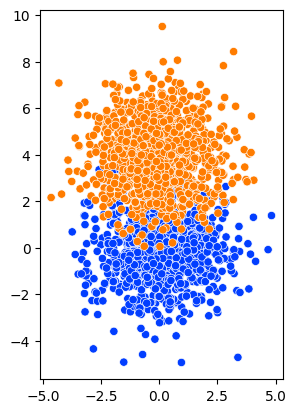

In [46]:
train_n_points = np.array([1000, 1000])
test_n_points = np.array([10000, 10000])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [0, 4]])
# Матрицы коварианцй
cov = np.array(
    [[[2, 0],
      [0, 2]],
     [[2, 0],
      [0, 2]]])

X_train, X_test, Y_train, Y_test = gen_train_test_smes(mean, cov, target, train_n_points, test_n_points)

sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=Y_train, palette="bright", legend=False)
plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90

Так выглядят хорошо откалиброванные классификаторы. Линии полученные от тестирования классификаторов совпадают с диниями ожидания и индекс Брайера близок к нулю.

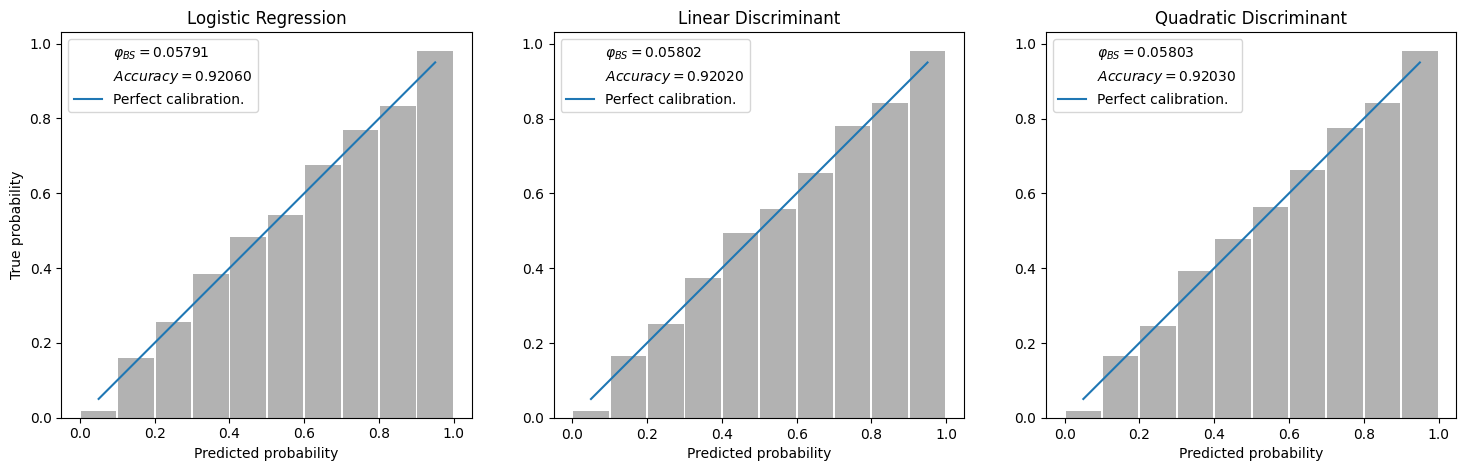

In [47]:
models = [  ("Logistic Regression", LogisticRegression()),
            ("Linear Discriminant", LinearDiscriminantAnalysis()),
            ("Quadratic Discriminant", QuadraticDiscriminantAnalysis())]

for _, model in models:
    model.fit(X_train, Y_train)

caliber_models(X_test, Y_test, models)

Получали почти одинаковые разделяющие поверхности:

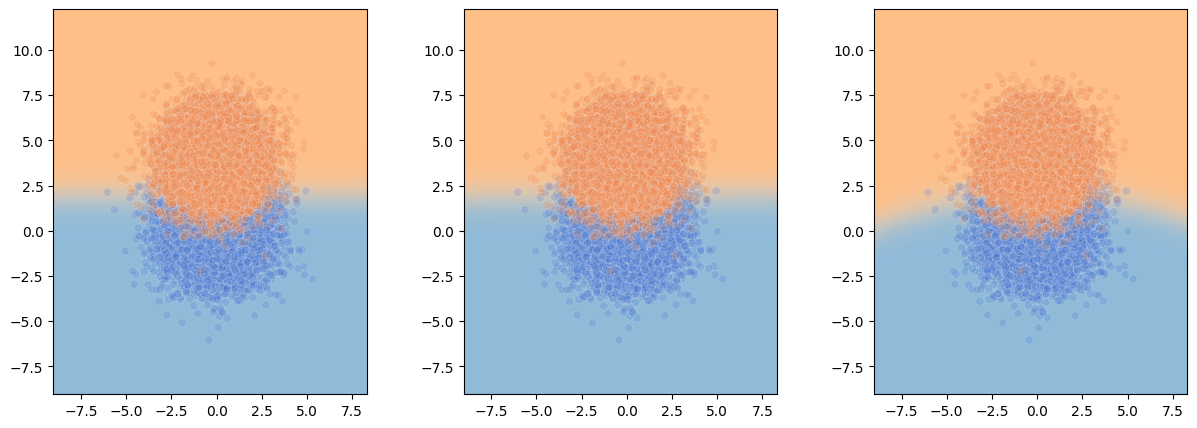

In [12]:
fig, axes = plt.subplots(1, 3)
axes = axes.flatten()
fig.set_size_inches(15,5)

for index, (name, model) in enumerate(models):
    draw_descision_surface(axes[index], X_test, Y_test, model)

Если кластеры сильно отдалены, то предсказания классификатора не будут совпадать с целевыми вероятностями. И индекс Брайера равен нулю, потому что для каждой точки данных предсказана верная метка класса, что говорит о хорошей калибровке. 

Диагональ не сформировалась просто потому, что нет точек, которые были бы под вопросом. В таком случае никакие вероятности не нужны. Классы и так отделяются легко. Но к сожалению в реальной жизни такого никогда не бывает.

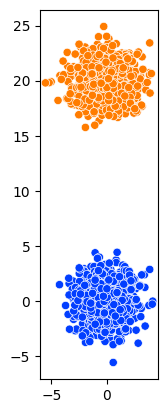

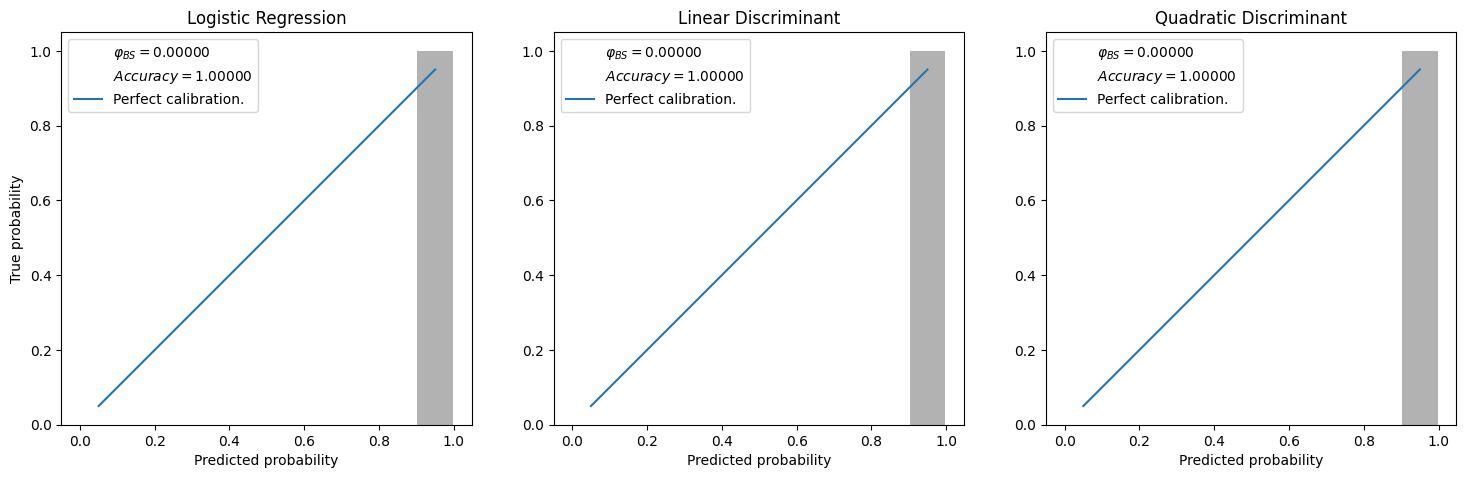

In [13]:
mean = np.array([[0, 0], [0, 20]])

X_train, X_test, Y_train, Y_test = gen_train_test_smes(mean, cov, target, train_n_points, test_n_points)

sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=Y_train, palette="bright", legend=False)
plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90

for _, model in models:
    model.fit(X_train, Y_train)
caliber_models(X_test, Y_test, models)

А если отобразим разделяющие поверхности, то увидим что переход между классами у логистической регрессии довольной плавный, а вот у линейного и квадратичного дискриминанта переход очень резкий.

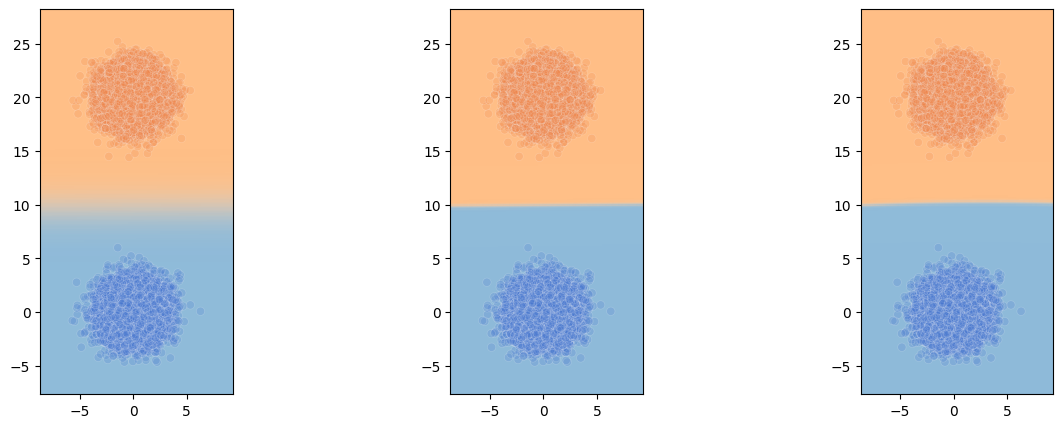

In [14]:
fig, axes = plt.subplots(1, 3)
axes = axes.flatten()
fig.set_size_inches(15,5)

for index, (name, model) in enumerate(models):
    draw_descision_surface(axes[index], X_test, Y_test, model)

Теперь сгенерируем данные посложнее. 

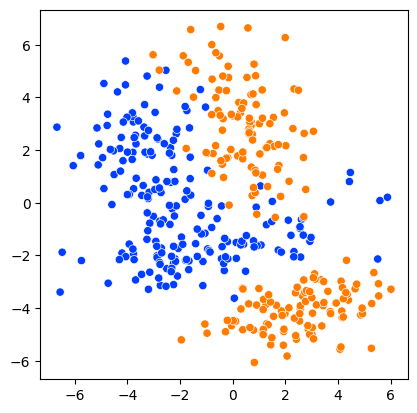

In [15]:
train_n_points = np.array([100, 100, 100, 100])
test_n_points = np.array([1000, 1000, 1000, 1000])
target = np.array([1, 1, 2, 2])
# Среднее центров гауссианов
mean = np.array([[0, -1.5], [-3, 1.5], [0.5, 3], [2.5, -4]])
# Матрицы коварианцй
cov = 1.5*np.array(
    [[[4, .5],
      [.5, .5]],
     [[1, -0.5],
      [-0.5, 2]],
     [[1, -0.5],
      [-0.5, 2]],
     [[2, 0.5],
      [0.5, 0.5]]
    ])
X_train, X_test, Y_train, Y_test = gen_train_test_smes(mean, cov, target, train_n_points, test_n_points)
sns.scatterplot(x=X_train[:,0], y=X_train[:,1], hue=Y_train, palette="bright", legend=False)
plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90

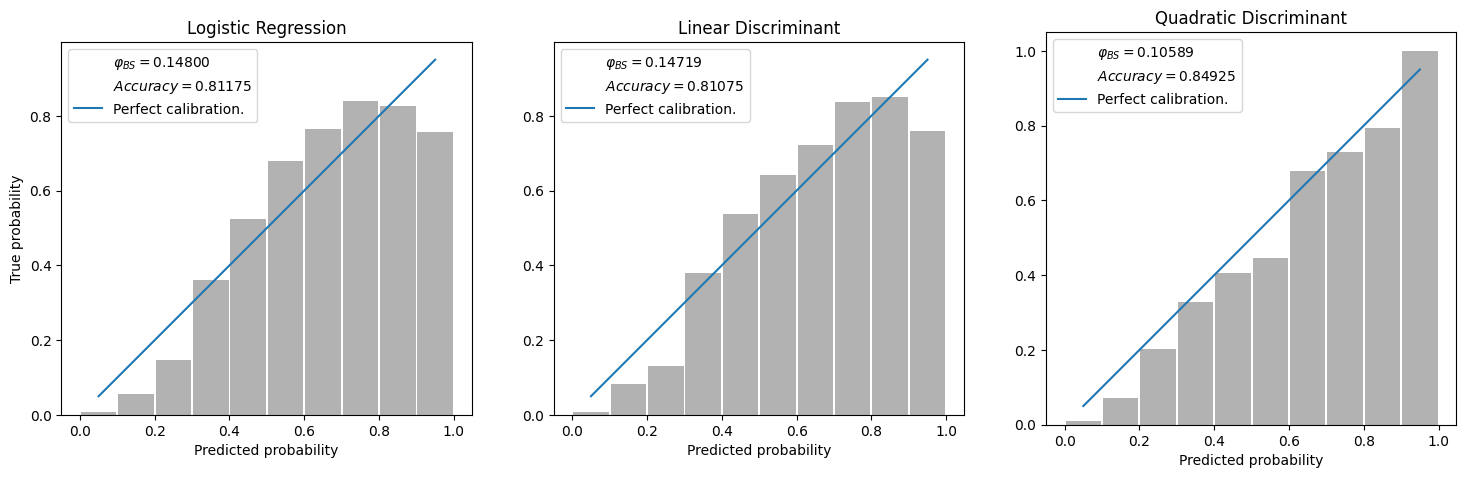

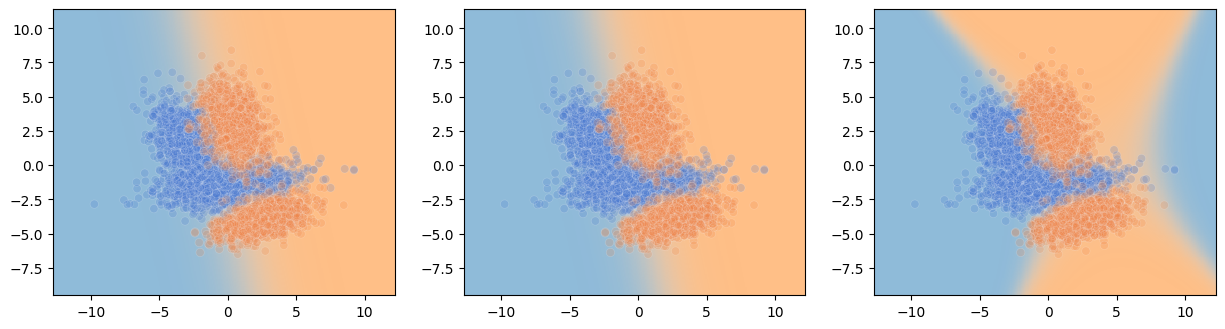

In [16]:
for _, model in models:
    model.fit(X_train, Y_train)

caliber_models(X_test, Y_test, models)

fig, axes = plt.subplots(1, 3)
fig.set_size_inches(15,5)
axes = axes.flatten()

for index, (name, model) in enumerate(models):

    draw_descision_surface(axes[index], X_test, Y_test, model)

Тут мы уже видим не самые точные предсказания вероятностей. LDA и логистическая регрессия занижают вероятность при предсказании вероятностей на отрезке от $0$ до $0.3$ и сильно завышает вероятности на отрезке от $0.3$ до $0.8$. QDA тут показывает довольно близкие предсказания вероятностей, немного завышая вероятности ближе к 1.

В целом можно отметить, что и по доле правильных ответов и по близости предсказанной вероятности модель QDA работает лучше. Тем не менее, это скорее приятная случайность, потому что вероятностное предположение, лежащее в основе QDA не выполняется.

## Методы улучшения калибровки классификаторов

После того, как мы выявили, что классификатор плохо откалиброван необходимо его откалибровать.

Самым простым методом является масштабирование Платта, которое заключается в обучении параметризованного логистического сигмоида:

$$\sigma(s;\mu,\alpha)=\frac{1}{1+e^{-\alpha(s-\mu)}}.$$

Этот метод оригинально был предложен не для калибровки классификаторов, а для преобразования предсказаний классификаторов выдающих некоторую оценку принадлежности классам (не являющуюся вероятностью) в вероятность.

Этот метод можно применить "из коробки" импортировав класс `CalibratedClassifierCV`, тут по названию мы уже знаем, что будет использоваться подход кросс-валидации.

Классификатор дополнительно оборачивается в `FrozenEstimator`, которые при вызове его метода `fit` не делает ничего. Это нужно, чтобы классификатор не обучался на переданных данных, а только обучались параметры для калибровки.

В реализации `CalibratedClassifierCV` есть также метод калибровки `isotonic`, который строит ступенчатую неубывающую функцию для преобразования вероятности так, чтобы минимизировать расстояние между идеальной прямой и предсказываемой.

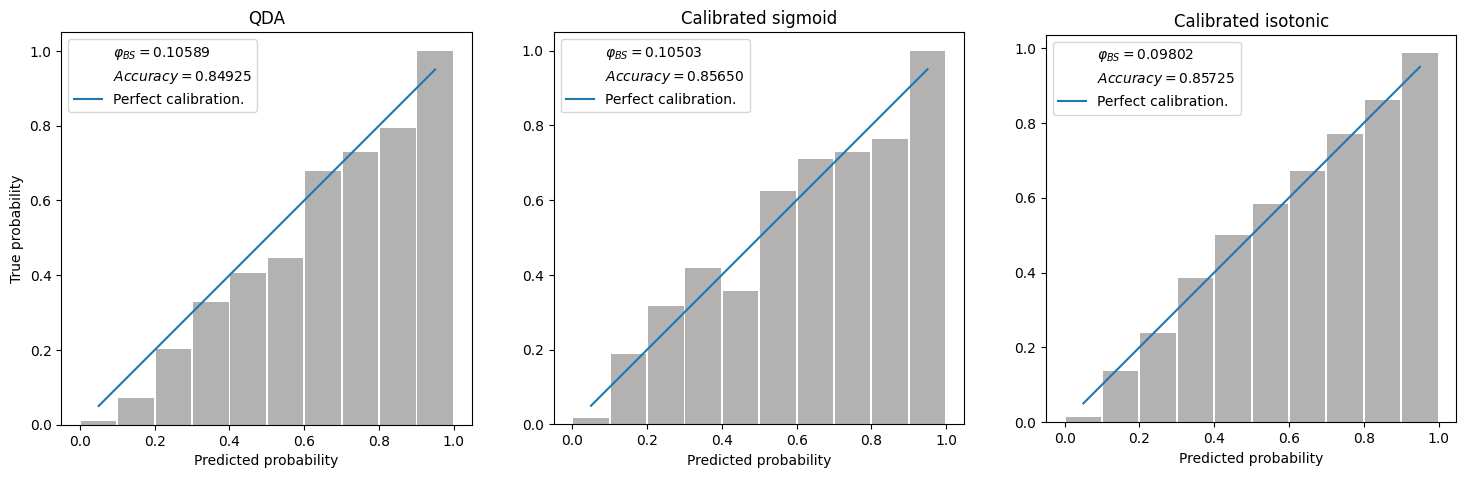

In [17]:
model = QuadraticDiscriminantAnalysis()
model.fit(X_train, Y_train)

caliber_sigmoid = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid", cv=5)
caliber_sigmoid.fit(X_test, Y_test)

caliber_isotonic = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic", cv=5)
caliber_isotonic.fit(X_test, Y_test)


models_calibration = [("QDA", model), ("Calibrated sigmoid", caliber_sigmoid), ("Calibrated isotonic", caliber_isotonic)]

caliber_models(X_test, Y_test, models_calibration)

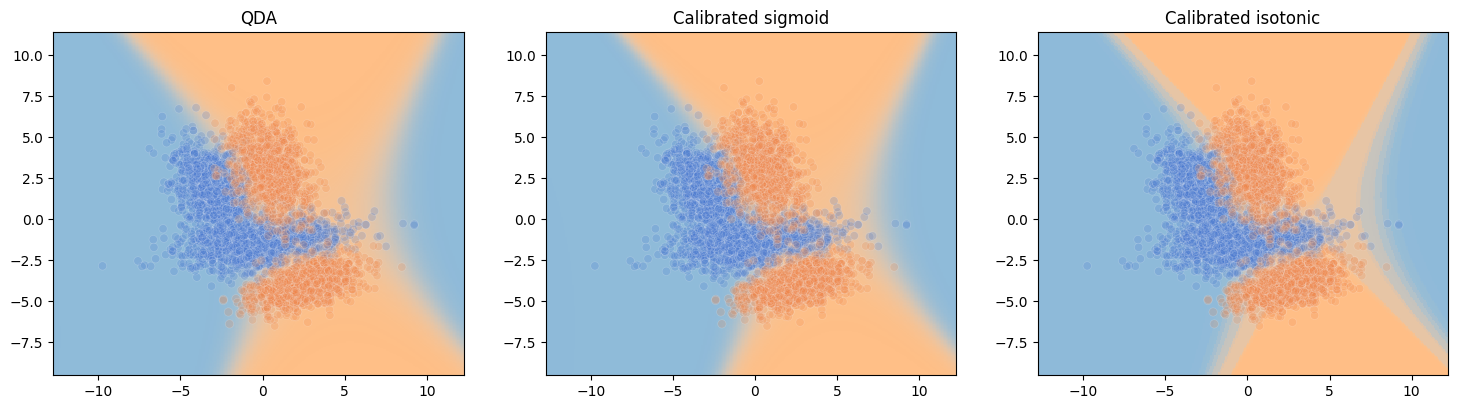

In [18]:
fig, ax = plt.subplots(1,3)
fig.set_size_inches(18,6)
for index, (name, modell) in enumerate(models_calibration):
    draw_descision_surface(ax[index], X_test, Y_test, modell)
    ax[index].set_title(name)

Как мы видим, при калибровке Платта переход между классами стал более резким, а при изотонической калибровке поверхность стала ступенчатой.

## Метрики, основанные на предсказанной вероятности

Ранее мы рассматривали простые метрики классификации, основанные на строгом предсказании классов. Но как мы уже заметили на примере калибровки, для моделей, предсказывающих вероятности, требуется уметь сравнивать и качество предсказываемых вероятностей. Для этого есть отдельный метрики.

### Кривая Precision-Recall

Кривая Точность-Полнота строится для одного выбранного класса. Предсказания сортируются по убыванию уверенности, далее считаются точность и полнота для каждого порога уверенности. Далее строится график, где по оси $x$ полнота, а по оси $y$ точность. Иногда рисуют и смотрят на саму кривую. Из кривой можно получить одно число - площадь под кривой, этот показатель называют **средней точность** (Average Precision, AP). Показатель принимает значение от 0 до 1 и чем он выше тем лучше.

Обычно кривая представляет собой убывающую ступенчатую функцию. Она имеет такой вид потому что по мере убывания уверенности отметок появляются неверно классифицированные отметки, поэтому точность начинает со значения 1 и убывает, но добавляются верно классифицированные отметки, поэтому полнота возрастает от $0$ до $1$.

Если классов несколько, то для каждого класса кривая строится независимо, потом вычисляется показатель средней точности для каждого класса независимо, а затем усредняется, так получается показатель **сбалансированной средней точности** (mean Average Precision, mAP).

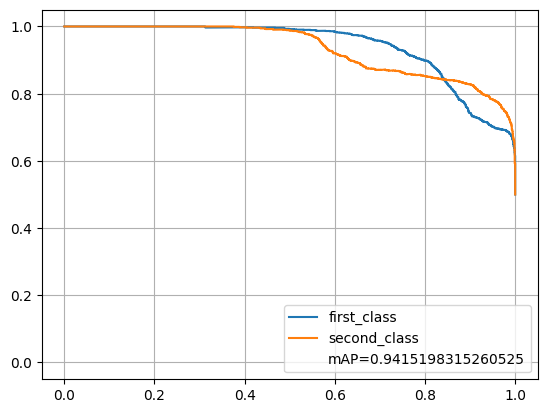

In [19]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve

# Пример PR
prob = model.predict_proba(X_test)
precision, recall, _ = precision_recall_curve(Y_test, prob[:,0], pos_label=1)
plt.plot(recall, precision, label="first_class")
precision, recall, _ = precision_recall_curve(Y_test, prob[:,1], pos_label=2)
plt.plot(recall, precision, label="second_class")
plt.plot([0], [0], c="w", label=f"mAP={average_precision_score(Y_test, prob[:,0])}")
plt.legend()
plt.grid()

По сути этот график отражает то, какой баланс между точностью и полнотой мы можем получить, если сдвинем границу принятия принадлежности объектов классам. 

В случае двух классов мы принимаем, что объект принадлежит классу, если предсказанная вероятность больше $0.5$. Но мы можем сказать, что первый класс нам важнее и нам необходимо находить больше объектов этого класса. Мы можем сместить порог принятия с $0.5$ до $0.4$, мы повысим полноту, но уменьшим точность. Этот график показывает связь точности и полноты.

Если какая-то модель лучше, то её кривая будет проходит над кривой худшей модели.

### ROC-кривая и показатель AUC

Название расшифровывается как Receiver Operating Characteristic. Красивого перевода у этого термина нет, обычно так и употребляется: "ROC-кривая".

Метод построения совпадает с кривой Precision-Recall, но вместо точности и полноты строится на основании двух показателей: **чувствительности** (sensitivity, True Positive Rate, TPR) и **специфичности** (specificity, True negative Rate, TNR), которые рассчитываются по следующим формулам:

$$TPR=\frac{TP}{TP+FN},$$

$$TNR=\frac{TN}{FP+TN}.$$

Показатели специфичности и чувствительности обычно используют в сфере медицины при проверке работы медицинских тестов.

Важно заметить, что чувствительность это полнота, просто носит другое имя из-за сферы применения. Показатель всё также отражает вероятность получить положительный результат теста при наличии болезни.

А вот специфичность это новый для нас показатель. Специфичность отражает вероятность получить отрицательный результат теста, при условии отсутствия болезни. 

Для построения кривой на оси $x$ откладывается показатель $1-Специфичность$, также называемый FPR (False Positive Rate), он отражает шанс положительного срабатывания для здорового человека. А по оси $y$ откладывается показатель чувствительности.

Кривая имеет следующие характеристики:
- Кривая всегда начинается из точки $(0,0)$, когда никакие объект не получают положительные предсказания. 
- Кривая всегда заканчивается в точке $(1,1)$, когда абсолютно все объекты получают положительны предсказания
- Случайный классификатор даст прямую идущую из точки $(0,0)$ в точку $(1,1)$.
- Чем ближе прямая к левому верхнему углу тем лучше.


Метрика ROC-AUC (Area Under Curve) это площадь под ROC-кривой, чем она больше, тем лучше.

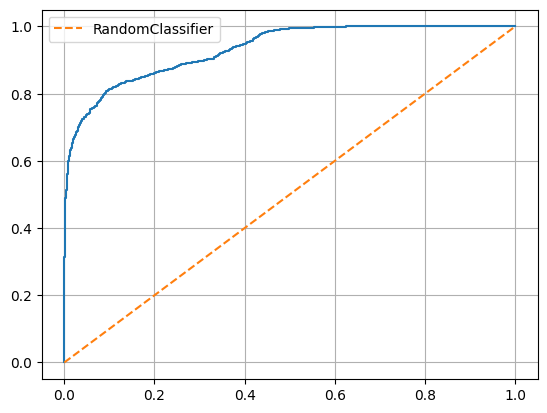

In [20]:
fpr, tpr, thresholds = roc_curve(Y_test, model.predict_proba(X_test)[:,0], pos_label=1)
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], label="RandomClassifier", ls="dashed")
plt.grid()
plt.legend()

## Сглаживание отметок

Ещё один трюк с обучением вероятностных моделей это сглаживание отметок. Вместо обучения one-hot вектора вероятностей можно целевой класс кодировать вероятностью $t\in [0,1]$, а остальные классы вероятностью $\frac{1-t}{K-1}$. Так мы получим вектор:

$$\left(\frac{1-t}{K-1}, \dots, \frac{1-t}{K-1}, t, \frac{1-t}{K-1},\dots, \frac{1-t}{K-1}\right).$$

Такой трюк часто позволяет повысить качество обучения модели. 

- Это работает как регуляризация, снижая уверенность модели в своих ответах (почти как Лапласовское сглаживание).
- Часто это улучшает калибровку модели.
- Помогает бороться с шумом в наборе данных. Если в наборе данных много шума, то такой трюк уменьшает его влияние на результат обучения.

В sci-kit learn нет реализации регрессии со сглаживанием отметок, но мы можем реализовать его сами с помощи библиотеки PyTorch. Это библиотека, которая позволяет производить с тензорами разные операции и самое главное - автоматически вычислять градиенты по этим операциям. 

In [21]:
from sklearn.base import ClassifierMixin
import torch
from torch.nn import Linear, Softmax, Sequential, CrossEntropyLoss
from torch.optim import Adam

def create_my_logistic_regression(input_dim, num_classes):
    return Sequential(
        Linear(input_dim, num_classes), # линейный слой для предсказания шансов
        Softmax(dim=-1)                 # функция softmax для получения вероятности
    )

class MyModel(ClassifierMixin):
    def __init__(self, smoothing=0.1, alpha = 0.1):
        self.model = None
        self.smoothing = smoothing
        self.alpha = alpha
    
    def fit(self, X, Y):
        self.classes_ = np.unique(Y)
        num_classes = self.classes_.shape[0]
        # функция потери
        loss = CrossEntropyLoss(label_smoothing=self.smoothing)
        # Создание модели
        self.model = create_my_logistic_regression(X.shape[1], num_classes)
        # Оптимизатор методом градиентного спуска
        optimizer = Adam(self.model.parameters(), lr=1, weight_decay=self.alpha)
        # количество эпох
        epochs = 100
        # приведение массивов к типу pytorch
        X_train_torch = torch.from_numpy(X).float()
        Y_train_torch = torch.from_numpy(Y-1).long()
        # перевод модели в режим обучения
        self.model.train()
        for i in range(epochs):
            # обнуление градиентов
            optimizer.zero_grad()
            # Получение предсказаний
            predicts = self.model(X_train_torch)
            # Вычисление функции ошибки
            result = loss(predicts, Y_train_torch)
            # вычисление градиента
            result.backward()
            # градиентный шаг параметров модели
            optimizer.step()
        # перевод модели в режим применения
        self.model.eval()
        # возврат объекта для соблюдения соглашения sci-kit learn
        return self
    
    def predict_proba(self, x):
        with torch.no_grad():
            return self.model(torch.tensor(x).float()).numpy()

Сравним результаты обученных моделей. Немного увеличилась точность, индекс Байера не изменился, тем не менее "на глаз" прямая стала ближе к диагонали.

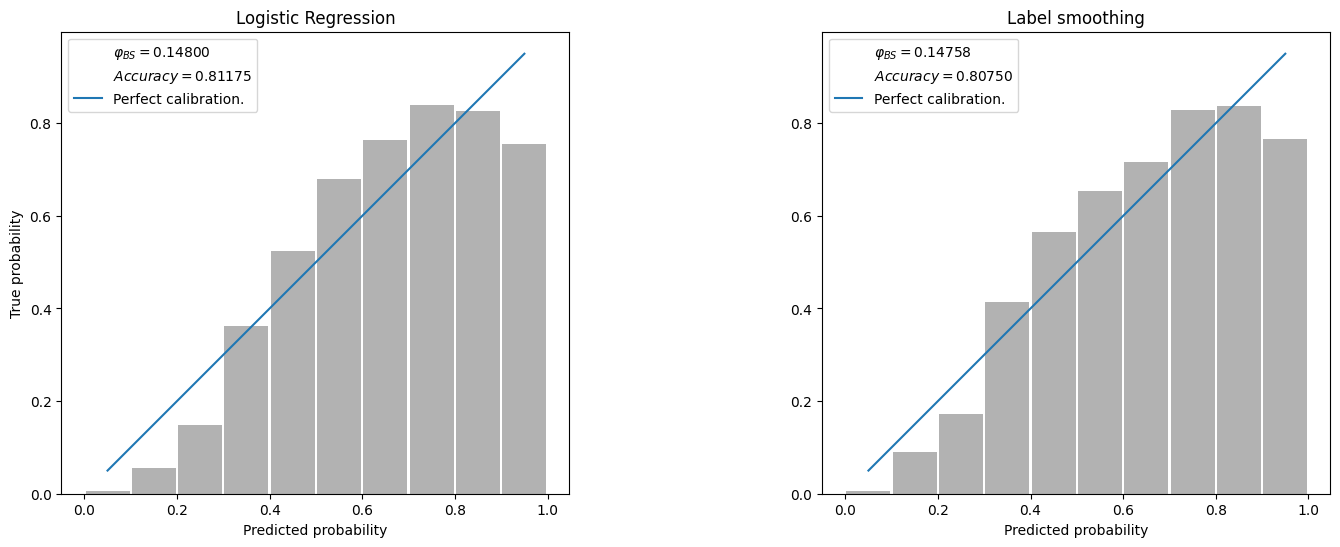

In [43]:
models = [  ("Logistic Regression", LogisticRegression()),
            ("Label smoothing", MyModel(smoothing=0.1, alpha=0.1))]

for _, model in models:
    model.fit(X_train, Y_train)

caliber_models(X_test, Y_test, models)

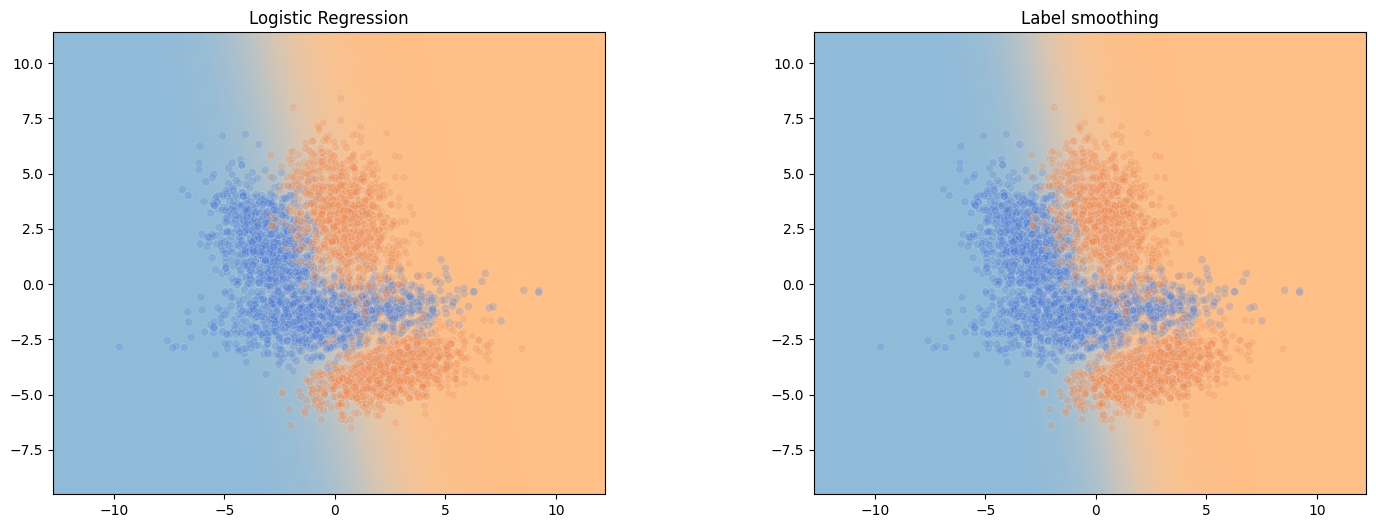

In [44]:
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(18,6)
for index, (name, modell) in enumerate(models):
    draw_descision_surface(ax[index], X_test, Y_test, modell)
    ax[index].set_title(name)

## Нелинейная классификация

Важно отметить, что пока мы рассматривали лишь довольно простые случаи: всё происходит в двумерном пространстве и точки можно было разделить прямой.

Но для логистической регрессии, как и для обычной линейной регрессии, нет никаких препятствий для того, чтобы сделать некоторые преобразования над данными, чтобы получить хорошее представление, где начнёт работать логистическая регрессия.

Рассмотрим пример. Первый класс имеет равномерное распределение на квадрате, а второй $-$ нормальное распределение.

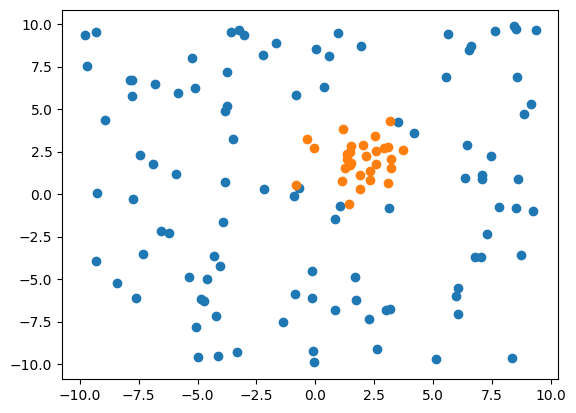

In [24]:
# Генерация точек класса:
X1 = np.random.uniform(-10, 10, size=(100,2))
# Генерация точек второго класса
X2 = np.random.multivariate_normal([2,2], [[1,0.2],[0.2,1]], (30))
# отрисовка точек
plt.scatter(X1[:, 0], X1[:, 1])
plt.scatter(X2[:, 0], X2[:, 1])
X = np.concatenate([X1,X2], axis=0)
Y = np.concatenate([np.ones(X1.shape[0]), 2*np.ones(X2.shape[0])])

Линейная разделяющая поверхность явно не подходит:

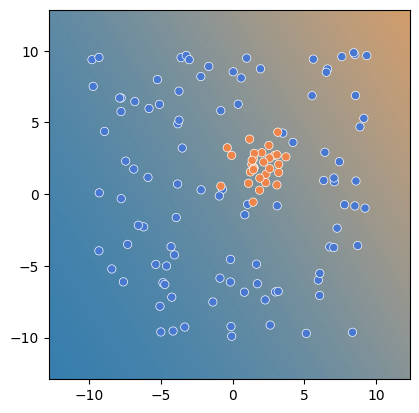

In [25]:
model = LogisticRegression()
model.fit(X,Y)
ax = plt.subplot()
draw_descision_surface(ax, X, Y, model,scatter_alpha=1,mesh_alpha=1)

А вот если извлечь полиномиальные признаки второй степени, то мы получим прекрасную разделяющую поверхность. С такими признаками модель как раз сможет строить эллипсы в двумерном пространстве.

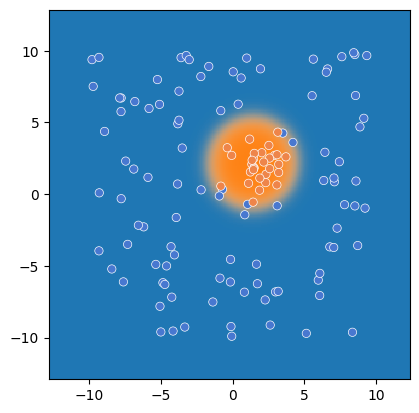

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LogisticRegression()
    )

model.fit(X,Y)
ax = plt.subplot()
draw_descision_surface(ax, X, Y, model, scatter_alpha=1, mesh_alpha=1)

Причём такой подход будет работать и для для более сложных данных:

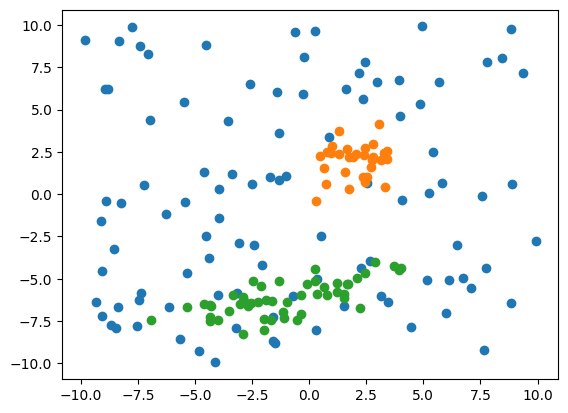

In [27]:
# Генерация точек класса:
X1 = np.random.uniform(-10, 10, size=(100,2))
# Генерация точек второго класса
X2 = np.random.multivariate_normal([2,2], [[1,0.2],[0.2,1]], (30))
# Генерация точек третьего класса
X3 = np.random.multivariate_normal([-1,-6], [[7,2],[2,1]], (50))
# отрисовка точек
plt.scatter(X1[:, 0], X1[:, 1])
plt.scatter(X2[:, 0], X2[:, 1])
plt.scatter(X3[:, 0], X3[:, 1])
X = np.concatenate([X1, X2, X3], axis=0)
Y = np.concatenate([np.ones(X1.shape[0]), 2*np.ones(X2.shape[0]), 3*np.ones(X3.shape[0])])

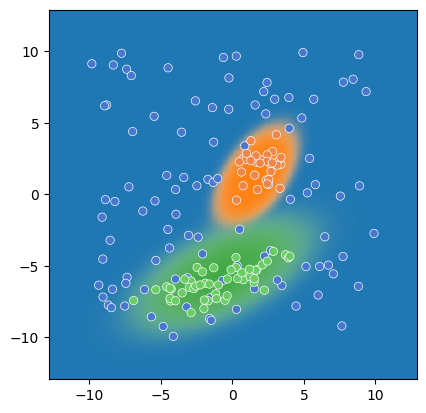

In [28]:
model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LogisticRegression(max_iter=500)
    )

model.fit(X,Y)
ax = plt.subplot()
draw_descision_surface(ax, X, Y, model, scatter_alpha=1, mesh_alpha=1)

Также мы можем захотеть отделять кольца друг от друга.

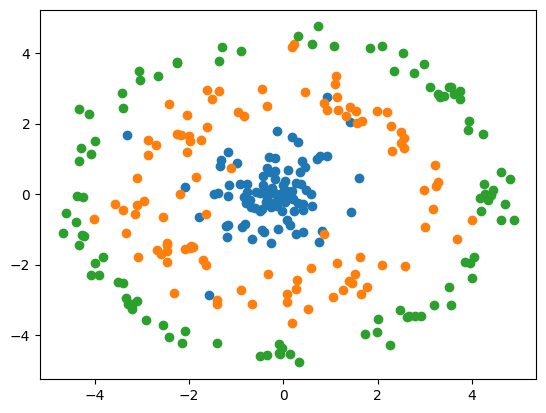

In [29]:
radiuses = [0, 3, 4.5]
sigmas = [1, 0.5, 0.2]
classes = [1, 2, 3]
N = 100
X = []
Y = []
for r, sigma, c in zip(radiuses, sigmas, classes):
    angles = np.random.uniform(0, 2 * np.pi, N)
    radius = np.random.normal(r, sigma, N)
    X1 = radius * np.cos(angles)
    X2 = radius * np.sin(angles)
    plt.scatter(X1, X2)
    X.append(np.hstack([X1[:,None], X2[:,None]]))
    Y.append(np.ones(N) * c)
X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)

С тремя классами всё работает и с полиномиальными признаками второй степени:

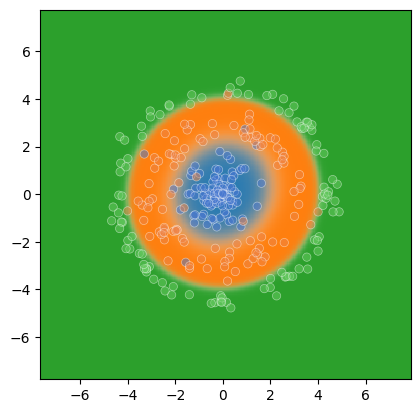

In [30]:
model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LogisticRegression(max_iter=500)
    )

model.fit(X,Y)
ax = plt.subplot()
draw_descision_surface(ax, X, Y, model, scatter_alpha=0.5, mesh_alpha=1)

А если сделать внутреннее и внешнее кольца одного класса всё работать перестанет:

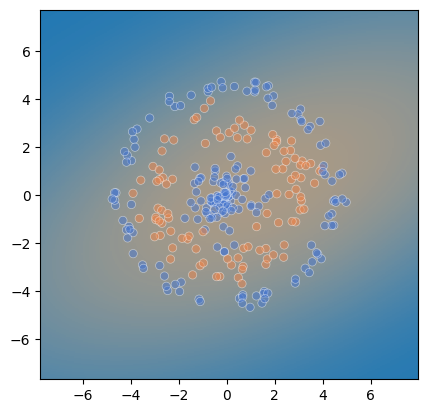

In [31]:
radiuses = [0, 3, 4.5]
sigmas = [1, 0.5, 0.2]
classes = [1, 2, 1]
N = 100
X = []
Y = []
for r, sigma, c in zip(radiuses, sigmas, classes):
    angles = np.random.uniform(0, 2 * np.pi, N)
    radius = np.random.normal(r, sigma, N)
    X1 = radius * np.cos(angles)
    X2 = radius * np.sin(angles)
    X.append(np.hstack([X1[:,None], X2[:,None]]))
    Y.append(np.ones(N) * c)
X = np.concatenate(X, axis=0)
Y = np.concatenate(Y, axis=0)

model = make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        LogisticRegression(max_iter=500)
    )

model.fit(X,Y)
ax = plt.subplot()
draw_descision_surface(ax, X, Y, model, scatter_alpha=0.5, mesh_alpha=1)

И для правильной классификации потребуются уже полиномиальные признаки 4 степени:

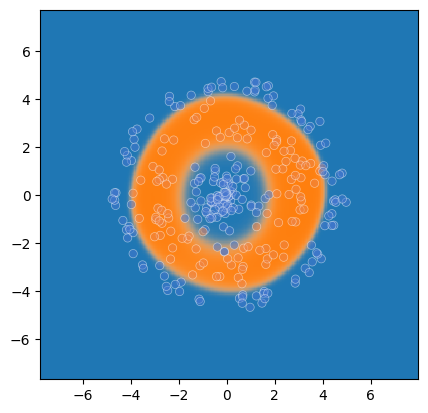

In [32]:
model = make_pipeline(
        PolynomialFeatures(degree=4, include_bias=False),
        LogisticRegression(max_iter=500)
    )

model.fit(X,Y)
ax = plt.subplot()
draw_descision_surface(ax, X, Y, model, scatter_alpha=0.5, mesh_alpha=1)

# Домашнее задание:
- Объясните почему в примере выше если мы рассматриваем три кольца, каждое из которых принадлежит разному классу, полинома второй степени достаточно, а для случая когда внутреннее и внешнее кольца принадлежат одному классу требуется полином уже 4 степени.
- Доработайте класс с занятия по градиентному спуску, реализуйте обучение логистической регрессии, для бинарной классификации, должны сохраниться все добавленные ранее доработки (стохастический градиентный спуск, уменьшение темпа обучения и другие). 
    - Обязательно сохраните поддержку рисования поверхности функции ошибки (именно для этого мы и реализуем этот класс). Сравните получаемые линии уровня с линиями уровня в линейной регрессии.
    - Посмотрите как работает метод Ньютона.
- Обучите на наборе данных Ирисов Фишера классификаторы, предоставляющие вероятности (LDA, QDA, Логистическую регрессию). оцените влияние метода регуляризации на качество калибровки логистической регрессии. Оцените качество калибровки классификаторов, откалибруйте их. Посчитайте метрики mAP и ROC-AUC до калибровки и после. Как они поменялись? Нарисуйте PR- и ROC- кривые для каждого классификатора.
- Сравните на том же наборе ирисов Фишера модели логистической регрессии без и с сглаживанием отметок. 

Обученные веса [0.29559312 0.62614039]
Accuracy 0.925


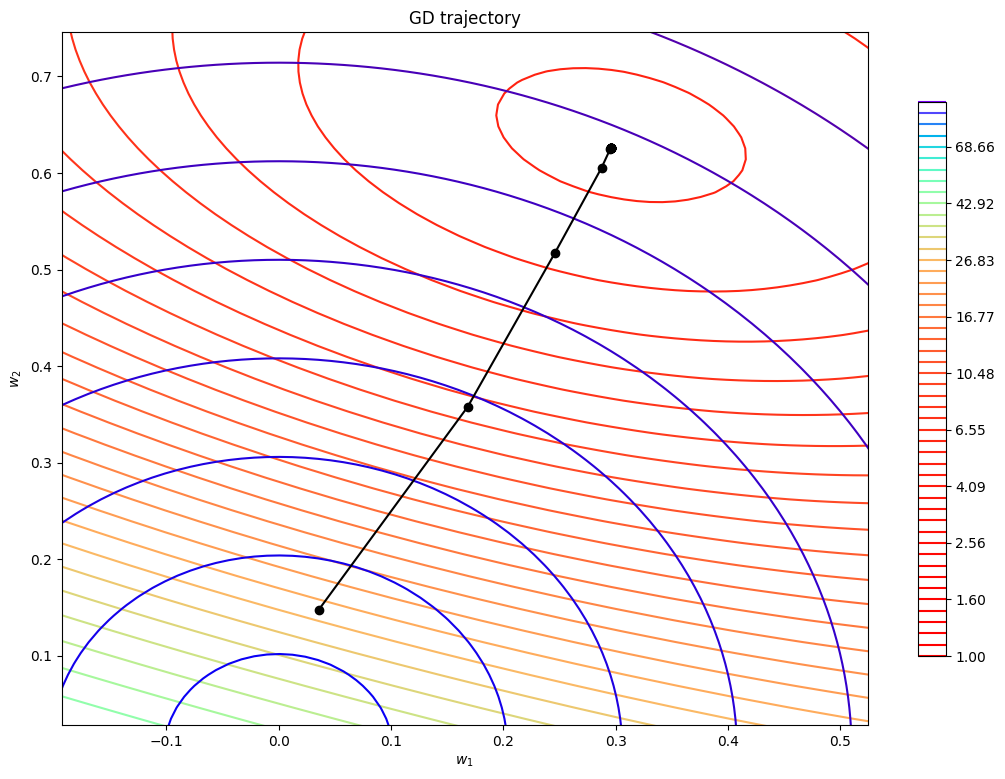

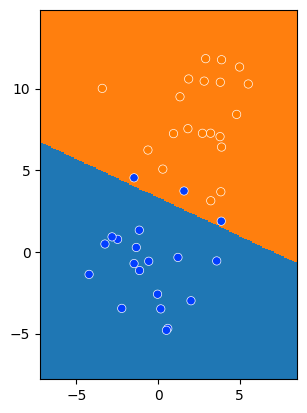

In [ ]:
# 2

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Literal
from sklearn.metrics import accuracy_score
class Regressor:
    
    def __init__(self, fit_intercept = False, lr=0.001, lr_decay=False, epochs=100, use_newton = False, stochastic=False, regularization:Literal["None","L1","L2"]="None", alpha=0.1, logistic_regr=False):
        self.fit_intercept = fit_intercept
        self.lr = lr  # темп обучения
        self.lr_decay = lr_decay  # уменьшение темпа обучения
        self.epochs = epochs
        self.use_newton = use_newton
        self.stochastic = stochastic
        self.regularization = regularization
        self.alpha = alpha
        self.logistic = logistic_regr
        self.w_list = []
        self.w = None
        self.w_0 = 0
        self.num_samples = None
        if self.regularization == "L1" and self.use_newton:
            raise Exception("Метод ньютона неприменим к L1 регуляризации.")
        
    def sigmoid(self, x, w, w_0):
        a = x @ w + w_0
        return 1 / (1 + np.exp(-a))
    
    def loss(self, x:np.ndarray, y:np.ndarray, w:np.ndarray):
        if self.logistic:
            p = self.sigmoid(x, w, self.w_0)
            y = y[:, None]
            main_loss = -np.sum(y * np.log(p) + (1 - y) * np.log(1 - p), axis=0)
            # main_loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
        else:
            main_loss = np.mean(np.power(np.dot(x, w) - y, 2), axis=0)
        if self.regularization == "None":# отдельно компонента функции ошибки и регуляризации для удобной отрисовки
            return main_loss, np.zeros_like(main_loss)
        elif self.regularization == "L2":
            reg_loss = self.alpha * np.linalg.norm(w, ord=2, axis=0)
            return main_loss, reg_loss
        elif self.regularization == "L1":
            reg_loss = self.alpha * np.linalg.norm(w, ord=1, axis=0)
            return main_loss, reg_loss
        
    def grad(self, x: np.ndarray, y: np.ndarray, w: np.ndarray):
        n = x.shape[0]
        if self.logistic:
            p = self.sigmoid(x, w, self.w_0)
            base_grad = (1 / n) * (x.T @ (p - y))
        else:
            base_grad = (2 / n) * (x.T @ (x @ w - y))
        if self.regularization == "L2":
            base_grad += 2 * self.alpha * w
        elif self.regularization == "L1":
            base_grad += self.alpha * np.sign(w)
        return base_grad

    def hessian(self, x: np.ndarray, y: np.ndarray, w: np.ndarray):
        n = x.shape[0]
        if self.logistic:
            p = self.sigmoid(x, w, self.w_0).flatten()
            R = np.diag(p * (1 - p))
            base_hessian = (1 / n) * (x.T @ R @ x)
        else:
            base_hessian = (2 / n) * (x.T @ x)

        if self.regularization == "L2":
            base_hessian += 2 * self.alpha * np.eye(x.shape[1])
        return base_hessian
            
    
    def init_w(self, n_dim):
        """ Функция начальной инициализации весов."""
        return np.random.normal(0, 1, (n_dim, 1))
    
    def fit(self, x, y):
        if self.fit_intercept:
            x = np.concatenate([np.ones((x.shape[0], 1)), x], axis=1)
        if self.stochastic:
            self.__fit_stochastic(x, y)
            return
        # инициализация весов
        self.num_samples = len(x)
        y = y.reshape(-1, 1)
        w = np.random.normal(0, 0.1, (x.shape[1], 1))
        if self.fit_intercept:
            w_list = [w[1:]]
        else:
            w_list = [w.copy()]

        for _ in range(0, self.epochs):
            grad = self.grad(x, y, w)  # Вычисление градиента
            if self.use_newton:  # Измените параметры модели
                # Вычисление Гессиана
                H = self.hessian(x, y, w)
                w = w - np.linalg.inv(H) @ grad
            else:
                w = w - self.lr * grad
            if self.fit_intercept:
                w_list.append(w[1:].copy())
            else:
                w_list.append(w.copy())
            if self.lr_decay or self.stochastic:
                self.lr *=0.9
        self.w_list = np.array(w_list)
        if self.fit_intercept:
            self.w = w[1:]
            self.w_0 = w[0]
        else:
            self.w = w

    def __fit_stochastic(self, x, y):
        self.num_samples = len(x)
        y = y.reshape(-1, 1)
        w = np.random.normal(0, 0.1, (x.shape[1], 1))
        if self.fit_intercept:
            w_list = [w[1:]]
        else:
            w_list = [w.copy()]
        batch_size = 10
        indexes = np.arange(x.shape[0])
        for _ in range(0, self.epochs):
            np.random.shuffle(indexes)
            for i in range(x.shape[0] // batch_size):
                indices = indexes[i * batch_size: (i + 1) * batch_size]
                grad = self.grad(x[indices], y[indices], w)  # Вычисление градиента
                if self.use_newton:  # Изменяем параметры модели
                    # Вычисление Гессиана
                    H = self.hessian(x, y, w)
                    w = w - np.linalg.inv(H) @ grad
                else:
                    w = w - self.lr * grad
                if self.fit_intercept:
                    w_list.append(w[1:].copy())
                else:
                    w_list.append(w.copy())
                self.lr *=0.98
        self.w_list = np.array(w_list)
        if self.fit_intercept:
            self.w = w[1:]
            self.w_0 = w[0]
        else:
            self.w = w
            
    def predict(self, x):
        if self.logistic:
            return self.sigmoid(x, self.w, self.w_0) > 0.5
        return x @ self.w
    
    def presict_proba(self, x):
        return self._sigmoid(x, self.w, self.w_0)
            
    
    def show_training(self, w_true, x, y):
        if self.w.shape[0] !=2:
            raise Exception("Веса должны быть размерности 2.")
        radius = 1
        w_true = self.w
        plt.figure(figsize=(13, 9))
        plt.title('GD trajectory')
        plt.xlabel('$w_1$')
        plt.ylabel('$w_2$')
        xmin, xmax = self.w_list[:, 0].min(), self.w_list[:, 0].max()
        centr_x = (xmin + xmax) / 2
        width_x = np.abs(xmin - xmax)
        ymin, ymax = self.w_list[:, 1].min(), self.w_list[:, 1].max()
        centr_y = (ymin + ymax) / 2
        width_y = np.abs(ymin - ymax)
        width = np.max([width_x, width_y]) / 2 * 1.5
        plt.xlim(centr_x - width, centr_x + width)
        plt.ylim(centr_y - width, centr_y + width)
        A, B = np.meshgrid(np.linspace(xmin - radius, xmax + radius, 200),
                           np.linspace(xmin - radius, xmax + radius, 200))
        W = np.vstack([A.ravel(), B.ravel()])
        loss, reg = self.loss(x, y, W)
        levels_loss = loss.reshape(A.shape)
        levels_reg = reg.reshape(A.shape)
        CS = plt.contour(A, B, levels_loss, levels=np.logspace(0, 2, num=50), cmap=plt.cm.rainbow_r)
        CB = plt.colorbar(CS, shrink=0.8, extend='both')
        CS = plt.contour(A, B, levels_reg, levels=np.linspace(0, 5*self.alpha, num=50), cmap=plt.cm.brg)
        plt.scatter(self.w_list[:, 0], self.w_list[:, 1], color="black")
        plt.plot(self.w_list[:, 0], self.w_list[:, 1], color="black")

        plt.show()


def generate_samples(n_points, mean, cov, target):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    return X, Y

def plot_classifier(X, Y, model = None):
    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    if model:
        x = np.linspace(xmin, xmax, 300)
        y = np.linspace(ymin, ymax, 300)
        # создаём две матрицы с координатами x и y
        x, y = np.meshgrid(x, y)
        # Преобразуем матрицу в строчку
        xx = x.reshape(-1,1)
        yy = y.reshape(-1,1)
        points = np.hstack([xx,yy])
        # Передаём строчку точек в функцию
        probs = model.predict(points)
        # Преобразуем строчку обратно в матрицу
        probs = probs.reshape(x.shape)
        # рисуем деление плоскости на классы
        plt.pcolormesh(x, y, probs, cmap="tab10",vmax=10)
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="bright", legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)


# np.random.seed(53)

np.random.seed(42)
n_points = np.array([20, 20])
target = np.array([0, 1])
mean = np.array([[0, 0], [3, 8]])
cov = np.array(
    [[[6, 0],
      [0, 6]],
      [[6, 0],
      [0, 6]]]
)
X, Y = generate_samples(n_points, mean, cov, target)

model = Regressor(fit_intercept=True, lr=0.4, lr_decay=False, epochs=20, use_newton=True, regularization="L2", alpha=0.01, logistic_regr=True, stochastic=False)
model.fit(X, Y)

print("Обученные веса", model.w.ravel())
print("Accuracy", accuracy_score(Y, model.predict(X)))
model.show_training(Y, X, Y)
plot_classifier(X, Y, model)

c:\Users\aniak\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,LDA,QDA,Logistic Regression,Logistic Regression L2,caliber-LDA,caliber-QDA,caliber-Logistic Regression,caliber-Logistic Regression L2
Brier score,0.192811,0.213013,0.235634,0.208989,0.318280,0.302556,0.302664,0.314607
mAP,0.907494,0.911153,0.938720,0.937960,0.929348,0.829723,0.920916,0.929663
ROC_AUC,0.953333,0.952593,0.960000,0.959259,0.954074,0.914815,0.950370,0.955556


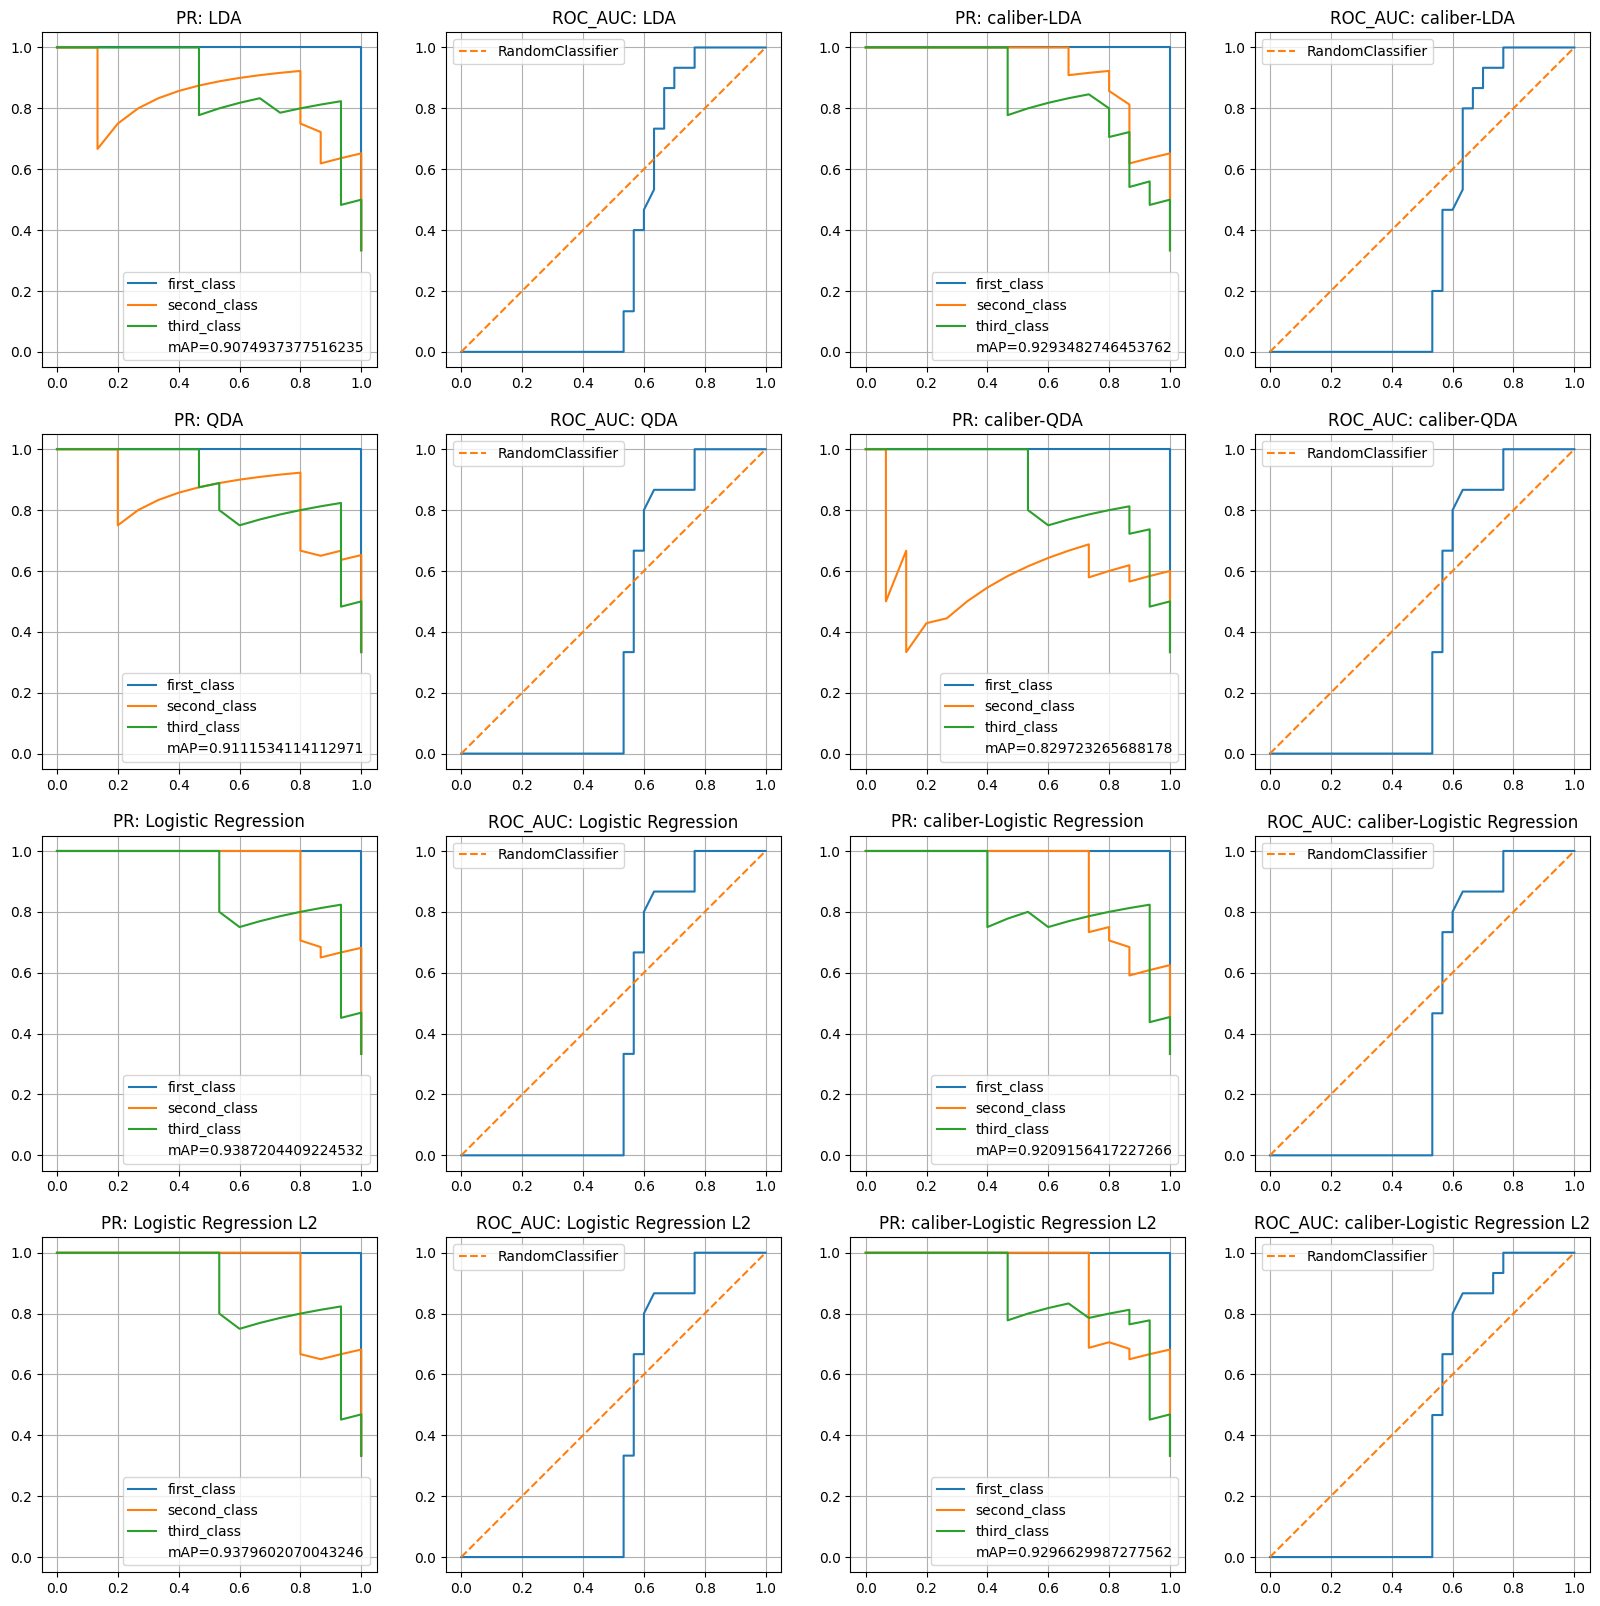

In [5]:
# 3

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, accuracy_score
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve
from sklearn.metrics import brier_score_loss, accuracy_score, average_precision_score, roc_auc_score


def draw_pr(model, name, i, j):
    prob = model.predict_proba(X_test)
    precision, recall, _ = precision_recall_curve((Y_test == 0).astype(int), prob[:,0])
    axes[i, j].plot(recall, precision, label="first_class")
    precision, recall, _ = precision_recall_curve((Y_test == 1).astype(int), prob[:,1])
    axes[i, j].plot(recall, precision, label="second_class")
    precision, recall, _ = precision_recall_curve((Y_test == 2).astype(int), prob[:,2])
    axes[i, j].plot(recall, precision, label="third_class")
    axes[i, j].plot([0], [0], c="w", label=f"mAP={average_precision_score(Y_test, prob)}")
    axes[i, j].set_title(f"PR: {name}")
    axes[i, j].set_aspect('equal')
    axes[i, j].legend()
    axes[i, j].grid()


def draw_roc_auc(model, name, i, j):
    fpr, tpr, _ = roc_curve(Y_test, model.predict_proba(X_test)[:,0], pos_label=1)
    axes[i, j].plot(fpr, tpr)
    axes[i, j].plot([0,1], [0,1], label="RandomClassifier", ls="dashed")
    axes[i, j].set_title(f"ROC_AUC: {name}")
    axes[i, j].set_aspect('equal')
    axes[i, j].grid()
    axes[i, j].legend()


iris_df = pd.read_csv("./iris.csv", index_col="Id") 
X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=5, test_size=0.3,
                                                    stratify=Y) # При разделении сохраняет соотношение классов


models = [
    (LinearDiscriminantAnalysis(), "LDA"),
    (QuadraticDiscriminantAnalysis(), "QDA"),
    (LogisticRegression(), "Logistic Regression"),
    (LogisticRegression(penalty="l2", C=4), "Logistic Regression L2")
    # (LogisticRegression(l1_ratio=0), "Logistic Regression L2")
]
cnt = 0
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
output_dict = dict()
for model, name in models:
    model.fit(X_train, Y_train)

    output_dict[name] = {
        "Brier score": brier_score_loss(Y_test, model.predict_proba(X_test)),
        "mAP": average_precision_score(Y_test, model.predict_proba(X_test)),
        "ROC_AUC": roc_auc_score(Y_test, model.predict_proba(X_test), multi_class='ovr', average='macro')
    }

    draw_pr(model, name, cnt // 2, cnt % 2)
    cnt += 1
    draw_roc_auc(model, name, cnt // 2, cnt % 2)
    cnt += 1

cnt = 0
for model, name in models:
    caliber_sigmoid = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid", cv=5)
    caliber_sigmoid.fit(X_test, Y_test)

    output_dict["caliber-" + name] = {
        "Brier score": brier_score_loss(Y_test, caliber_sigmoid.predict_proba(X_test)),
        "mAP": average_precision_score(Y_test, caliber_sigmoid.predict_proba(X_test)),
        "ROC_AUC": roc_auc_score(Y_test, caliber_sigmoid.predict_proba(X_test), multi_class='ovr', average='macro')
    }

    draw_pr(caliber_sigmoid, "caliber-" + name, cnt // 2, cnt % 2 + 2)
    cnt += 1
    draw_roc_auc(caliber_sigmoid, "caliber-" +name, cnt // 2, cnt % 2 + 2)
    cnt += 1


pd.DataFrame(output_dict)


# caliber_sigmoid = CalibratedClassifierCV(FrozenEstimator(model), method="sigmoid", cv=5)
# caliber_sigmoid.fit(X_test, Y_test)

# caliber_isotonic = CalibratedClassifierCV(FrozenEstimator(model), method="isotonic", cv=5)
# caliber_isotonic.fit(X_test, Y_test)


# models_calibration = [("QDA", model), ("Calibrated sigmoid", caliber_sigmoid), ("Calibrated isotonic", caliber_isotonic)]

# caliber_models(X_test, Y_test, models_calibration)

In [3]:
!pip install torch


[notice] A new release of pip available: 22.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


             Logistic Regression  Smoothing Logistic Regression
Brier score             0.235634                       0.657680
mAP                     0.938720                       0.597539
ROC_AUC                 0.960000                       0.763704


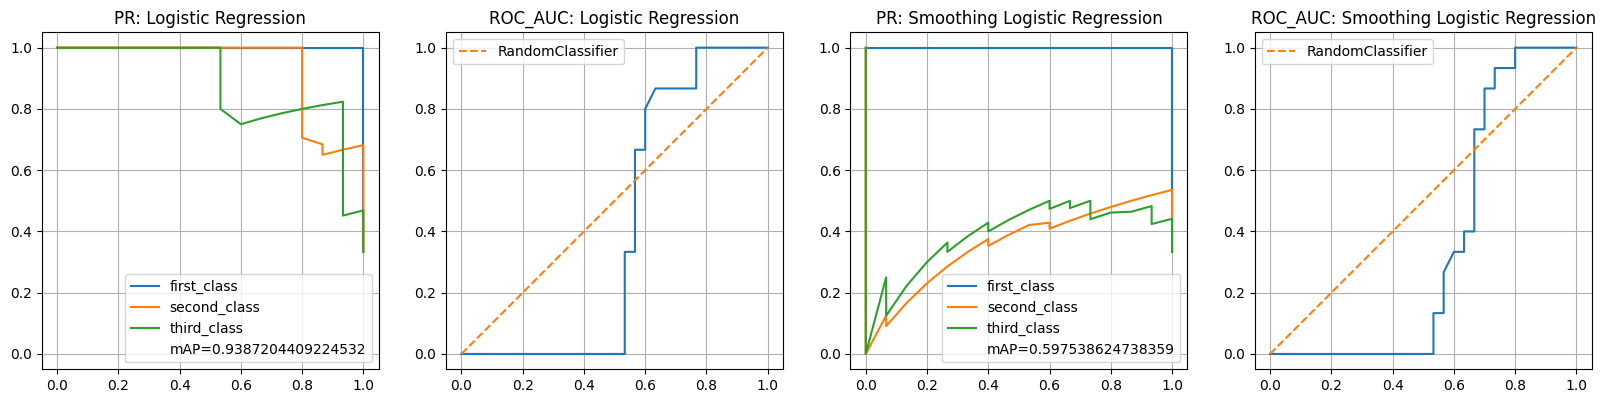

In [21]:
# 4

from sklearn.base import ClassifierMixin
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, accuracy_score
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve
from sklearn.metrics import brier_score_loss, accuracy_score, average_precision_score, roc_auc_score
import torch
from torch.nn import Linear, Softmax, Sequential, CrossEntropyLoss
from torch.optim import Adam

def create_my_logistic_regression(input_dim, num_classes):
    return Sequential(
        Linear(input_dim, num_classes), # линейный слой для предсказания шансов
        Softmax(dim=-1)                 # функция softmax для получения вероятности
    )

class SmoothingModel(ClassifierMixin):
    def __init__(self, smoothing=0.1, alpha = 0.1):
        self.model = None
        self.smoothing = smoothing
        self.alpha = alpha
    
    def fit(self, X, Y):
        self.classes_ = np.unique(Y)
        num_classes = self.classes_.shape[0]
        # функция потери
        loss = CrossEntropyLoss(label_smoothing=self.smoothing)
        # Создание модели
        self.model = create_my_logistic_regression(X.shape[1], num_classes)
        # Оптимизатор методом градиентного спуска
        optimizer = Adam(self.model.parameters(), lr=1, weight_decay=self.alpha)
        # количество эпох
        epochs = 100
        # приведение массивов к типу pytorch
        X_train_torch = torch.from_numpy(X).float()
        Y_train_torch = torch.from_numpy(Y).long()
        # print(Y_train_torch[:10])
        # перевод модели в режим обучения
        self.model.train()
        for i in range(epochs):
            # обнуление градиентов
            optimizer.zero_grad()
            # Получение предсказаний
            predicts = self.model(X_train_torch)
            # Вычисление функции ошибки
            result = loss(predicts, Y_train_torch)
            # вычисление градиента
            result.backward()
            # градиентный шаг параметров модели
            optimizer.step()
        # перевод модели в режим применения
        self.model.eval()
        # возврат объекта для соблюдения соглашения sci-kit learn
        return self
    
    def predict_proba(self, x):
        with torch.no_grad():
            return self.model(torch.tensor(x).float()).numpy()
        

def draw_pr(model, name, i):
    prob = model.predict_proba(X_test)
    precision, recall, _ = precision_recall_curve((Y_test == 0).astype(int), prob[:,0])
    axes[i].plot(recall, precision, label="first_class")
    precision, recall, _ = precision_recall_curve((Y_test == 1).astype(int), prob[:,1])
    axes[i].plot(recall, precision, label="second_class")
    precision, recall, _ = precision_recall_curve((Y_test == 2).astype(int), prob[:,2])
    axes[i].plot(recall, precision, label="third_class")
    axes[i].plot([0], [0], c="w", label=f"mAP={average_precision_score(Y_test, prob)}")
    axes[i].set_title(f"PR: {name}")
    axes[i].set_aspect('equal')
    axes[i].legend()
    axes[i].grid()


def draw_roc_auc(model, name, i):
    fpr, tpr, _ = roc_curve(Y_test, model.predict_proba(X_test)[:,0], pos_label=1)
    axes[i].plot(fpr, tpr)
    axes[i].plot([0,1], [0,1], label="RandomClassifier", ls="dashed")
    axes[i].set_title(f"ROC_AUC: {name}")
    axes[i].set_aspect('equal')
    axes[i].grid()
    axes[i].legend()
        

iris_df = pd.read_csv("./iris.csv", index_col="Id") 
X = iris_df[["SepalLengthCm", "SepalWidthCm"]].to_numpy()
encoder = LabelEncoder()
Y = encoder.fit_transform(iris_df["Species"])
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, random_state=5, test_size=0.3,
                                                    stratify=Y) # При разделении сохраняет соотношение классов
        
cnt = 0
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
models = [
    (LogisticRegression(), "Logistic Regression"),
    (SmoothingModel(smoothing=0.1 , alpha=0.1), "Smoothing Logistic Regression")
]
output_dict = dict()

for model, name in models:
    model.fit(X_train, Y_train)

    output_dict[name] = {
        "Brier score": brier_score_loss(Y_test, model.predict_proba(X_test)),
        "mAP": average_precision_score(Y_test, model.predict_proba(X_test)),
        "ROC_AUC": roc_auc_score(Y_test, model.predict_proba(X_test), multi_class='ovr', average='macro')
    }

    draw_pr(model, name, cnt % 4)
    cnt += 1
    draw_roc_auc(model, name, cnt % 4)
    cnt += 1

print(pd.DataFrame(output_dict))

In [ ]:
def ligistic_regression_example(n_points, mean, cov, target, penalty = None):
    X = []
    Y = []
    # Генерация точек из каждого гауссиана
    for i in range(0, n_points.shape[0]):
        X.append(np.random.multivariate_normal(mean=mean[i], cov=cov[i], size=n_points[i]))
        Y.append(np.ones(n_points[i])*target[i])
    X = np.concatenate(X)
    Y = np.concatenate(Y)
    # Обучение модели
    model = LogisticRegression(penalty=penalty)
    model.fit(X, Y)

    # Границы отрисовки
    xmin, xmax = X[:,0].min()-3, X[:,0].max()+3
    ymin, ymax = X[:,1].min()-3, X[:,1].max()+3
    x = np.linspace(xmin, xmax, 300)
    y = np.linspace(ymin, ymax, 300)
    # создаём две матрицы с координатами x и y
    x, y = np.meshgrid(x, y)
    # Преобразуем матрицу в строчку
    xx = x.reshape(-1, 1)
    yy = y.reshape(-1, 1)
    points = np.hstack([xx,yy])
    # Передаём строчку точек в функцию
    probs = model.predict_proba(points) # Получаем вероятности
    # Получаем самый вероятный класс
    predicts = probs.argmax(axis=1)
    # Получаем вероятность этого класса
    # probs = probs.max(axis=1)
    # Преобразуем строчку обратно в матрицу
    predicts = predicts.reshape(x.shape)
    # probs = probs.reshape(x.shape)
    probs = probs.reshape((*x.shape, -1))
    # рисуем деление плоскости на классы
    for i in range(model.classes_.shape[0]):
        plt.pcolormesh(x, y, np.ones_like(x) * target[i], cmap="tab10", vmin=1, vmax=10,
                   alpha=probs[:, :, i]) # Вероятность передаём в альфа-канал
    # рисование точек данных
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=Y, palette="bright", legend=False)
    plt.gca().set_aspect("equal") # фиксированное соотношение сторон, чтобы сохранялись углы 90
    plt.xlim(xmin, xmax)
    plt.ylim(ymin, ymax)


# Задаём параметры для генерации точек
# Количество точек
train_n_points = np.array([30000, 30000])
target = np.array([1, 2])
# Среднее центров гауссианов
mean = np.array([[0, 0], [5, 5]])
# Матрицы коварианцй
cov = np.array(
    [[[0.5, 0],
      [0, 0.5]],
     [[0.5, 0],
      [0, 0.5]]]
    )
ligistic_regression_example(train_n_points, mean, cov, target)
plt.xlim(-4,8)
plt.ylim(-4,8)